In [1]:
import pandas as pd
import numpy as np
import missingno as sms
import scipy.stats as stats
from pathlib import Path


#graficas

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture,BayesianGaussianMixture


In [2]:
sns.axes_style('whitegrid')

{'figure.facecolor': 'white',
 'axes.labelcolor': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'axes.axisbelow': True,
 'grid.linestyle': '-',
 'text.color': '.15',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'lines.solid_capstyle': 'round',
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'xtick.top': False,
 'ytick.right': False,
 'axes.grid': True,
 'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'grid.color': '.8',
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True,
 'xtick.bottom': False,
 'ytick.left': False}

# IMPORTAR LOS DATOS

In [3]:
def estado(x):
    if x == 'S':
        return 1
    elif x == 'N':
        return 2
    elif x == 'C':
        return 3
    else:
        return 0
    
def kruscal_effect(grupos, desp = True):
    if desp==True:
        H,p = stats.kruskal(*grupos)
    else:
        H,p = stats.kruskal(grupos)       
    n = sum(len(grupo) for grupo in grupos)
    k = len(grupos)
    epsilon_cuadrada = (H - k + 1) / (n - k)
    
    return epsilon_cuadrada, p

def crammers(tabla):
    chi2,p, dof, exp = stats.chi2_contingency(tabla)
    n = tabla.to_numpy().sum()
    min_dimension = min(tabla.shape) - 1 
    v_cramer = np.sqrt(chi2 / (n * min_dimension))
    return v_cramer,p
    
    
def delta_clip(x,y,alt='two-sided'):
    U,p = stats.mannwhitneyu(x,y,alternative=alt)
    n_1 = len(x)
    n_2 = len(y)
    
    delta_ = (   (2 * U / (n_1 * n_2)) - 1)
    
    return delta_, p 
        

In [4]:
df_escolarizado = pd.read_csv('candidatos_escolarizado_2023_2026.csv')
df_suayed = pd.read_csv('candidatos_suayed_2023_2026.csv')
df_escolarizado['acreditado']=df_escolarizado['acreditado'].apply(estado)
df_suayed['acreditado'] = df_suayed['acreditado'].apply(estado)

df_escolarizado['seleccionado'] =(df_escolarizado['acreditado']==1).astype("int")
ruta_datos = Path('../datos_scrapper')
archivos_resumen = [
    ruta_datos / 'unam_data-2023-2025' / f'resumen_{year}_escolarizado.csv'
    for year in (2023, 2024, 2025)
] + [
    ruta_datos / 'datos_scrapper-2026' / 'unam_data' / 'resumen_2026_escolarizado.csv'
]

resumen_escolarizado = pd.concat(
    [pd.read_csv(archivo) for archivo in archivos_resumen],
    ignore_index=True
)

claves = ['year', 'modalidad', 'codigo_carrera', 'plantel']
columnas_resumen = claves + [
    'aciertos_minimos', 'oferta', 'aspirantes',
    'presentaron_examen', 'seleccionados'
]

df_escolarizado = df_escolarizado.merge(
    resumen_escolarizado[columnas_resumen],
    on=claves,
    how='left',
    validate='many_to_one'
)

df_escolarizado['margen_sobre_minimo'] = (
    df_escolarizado['aciertos'] - df_escolarizado['aciertos_minimos']
)
df_escolarizado['alcanza_minimo'] = (
    df_escolarizado['aciertos'] >= df_escolarizado['aciertos_minimos']
).astype('int8')

df_escolarizado[[
    'year', 'carrera', 'plantel', 'aciertos', 'aciertos_minimos',
    'margen_sobre_minimo', 'alcanza_minimo', 'seleccionado'
]].sample(10, random_state=42)

df_escolarizado.drop(['oferta', 'aspirantes', 'presentaron_examen','seleccionados','alcanza_minimo'],axis=1,inplace=True)
df_escolarizado['aciertos'] = df_escolarizado['aciertos'].dropna()

In [5]:
df_escolarizado.sample(5)

,year,modalidad,codigo_carrera,carrera,plantel,folio,aciertos,acreditado,detalles,seleccionado,aciertos_minimos,margen_sobre_minimo
52158,2023,escolarizado,205,INGENIERIA EN ALIMENTOS,FES CUAUTITLÁN,139366,49.0,0,NaN,0,57,-8.0
645733,2026,escolarizado,305,DERECHO,FACULTAD DE DERECHO,201786,NaN,2,NaN,0,105,NaN
309690,2024,escolarizado,305,DERECHO,FES ACATLÁN,238348,NaN,2,NaN,0,70,NaN
188657,2024,escolarizado,102,ARQUITECTURA,FES ARAGÓN,33869,NaN,2,NaN,0,80,NaN
633271,2026,escolarizado,301,ADMINISTRACION,FACULTAD DE CONTADURÍA Y ADMINISTRACIÓN,244789,108.0,1,NaN,1,108,0.0


In [6]:
df_suayed.sample(5)

,year,modalidad,codigo_carrera,carrera,plantel,folio,aciertos,acreditado,detalles
8713,2023,suayed,305,DERECHO,FACULTAD DE DERECHO,220486,50.0,0,NaN
24787,2024,suayed,310,RELACIONES INTERNACIONALES,FACULTAD DE CIENCIAS POLÍTICAS Y SOCIALES,251205,NaN,2,NaN
42838,2026,suayed,210,PSICOLOGIA,FES IZTACALA,129477,51.0,0,NaN
3879,2023,suayed,301,ADMINISTRACION,FACULTAD DE CONTADURÍA Y ADMINISTRACIÓN,222924,NaN,2,NaN
48435,2026,suayed,304,CONTADURIA,FACULTAD DE CONTADURÍA Y ADMINISTRACIÓN,223499,NaN,2,NaN


# cambiare el acreditado por un numero: 0->no acreditado, 1->acreditado, 2-> no presentado, 3->cancelado


In [7]:
df_escolarizado['detalles']=df_escolarizado['detalles'].fillna('sin detalle')
df_suayed['detalles']=df_suayed['detalles'].fillna('sin detalle')

el folio por ahora no es importante

In [8]:
df_escolarizado = df_escolarizado.drop('folio',axis=1)

analisis rapido

## ME ENFOCARE EN EL ESCOLARIZADO POR AHORA

In [9]:
df_escolarizado.describe().T

,count,mean,std,min,25%,50%,75%,max
year,682504.0,2024.483993,1.123471,2023.0,2023.0,2025.0,2025.0,2026.0
codigo_carrera,682504.0,231.654294,89.464796,101.0,202.0,210.0,304.0,440.0
aciertos,579984.0,59.741276,21.920074,0.0,42.0,55.0,74.0,120.0
acreditado,682504.0,0.387809,0.741998,0.0,0.0,0.0,0.0,3.0
seleccionado,682504.0,0.088011,0.283311,0.0,0.0,0.0,0.0,1.0
aciertos_minimos,682504.0,92.628632,17.104906,40.0,84.0,95.0,107.0,117.0
margen_sobre_minimo,579984.0,-32.793022,24.528999,-117.0,-51.0,-35.0,-15.0,76.0


In [10]:
df_escolarizado.isna().sum()

year                        0
modalidad                   0
codigo_carrera              0
carrera                     0
plantel                     0
aciertos               102520
acreditado                  0
detalles                    0
seleccionado                0
aciertos_minimos            0
margen_sobre_minimo    102520
dtype: int64

<Axes: >

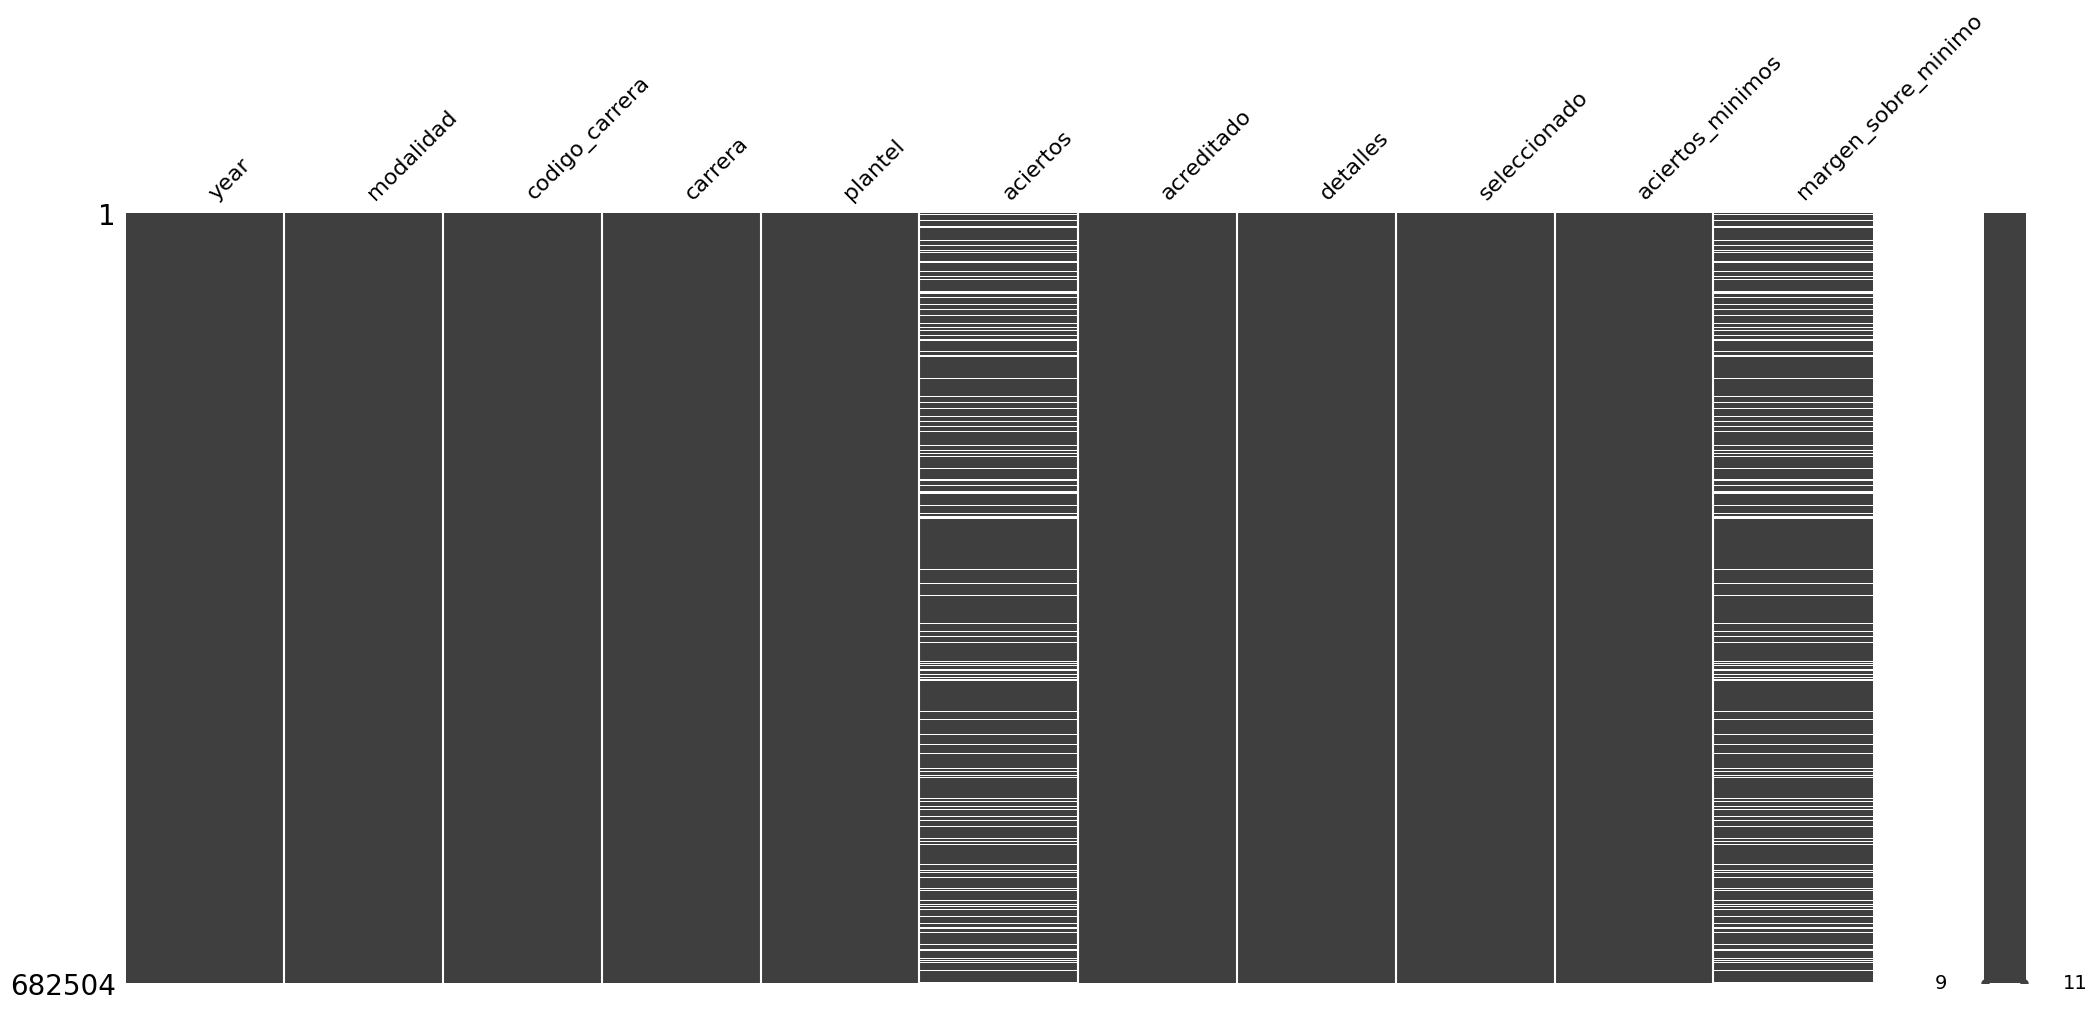

In [11]:
sms.matrix(df_escolarizado)

por ahora no tratare los nulos hasta despues

# EDA

# vista general de todos los a#os y carreras

In [12]:
#por si en algun momento es necesario

df_escolarizado_2023 = df_escolarizado.loc[df_escolarizado['year'] == 2023]
df_escolarizado_2024 = df_escolarizado.loc[df_escolarizado['year'] == 2024]
df_escolarizado_2025 = df_escolarizado.loc[df_escolarizado['year'] == 2025]
df_escolarizado_2026 = df_escolarizado.loc[df_escolarizado['year'] == 2026]

arr_year = [df_escolarizado_2023,df_escolarizado_2024,df_escolarizado_2025,df_escolarizado_2026]


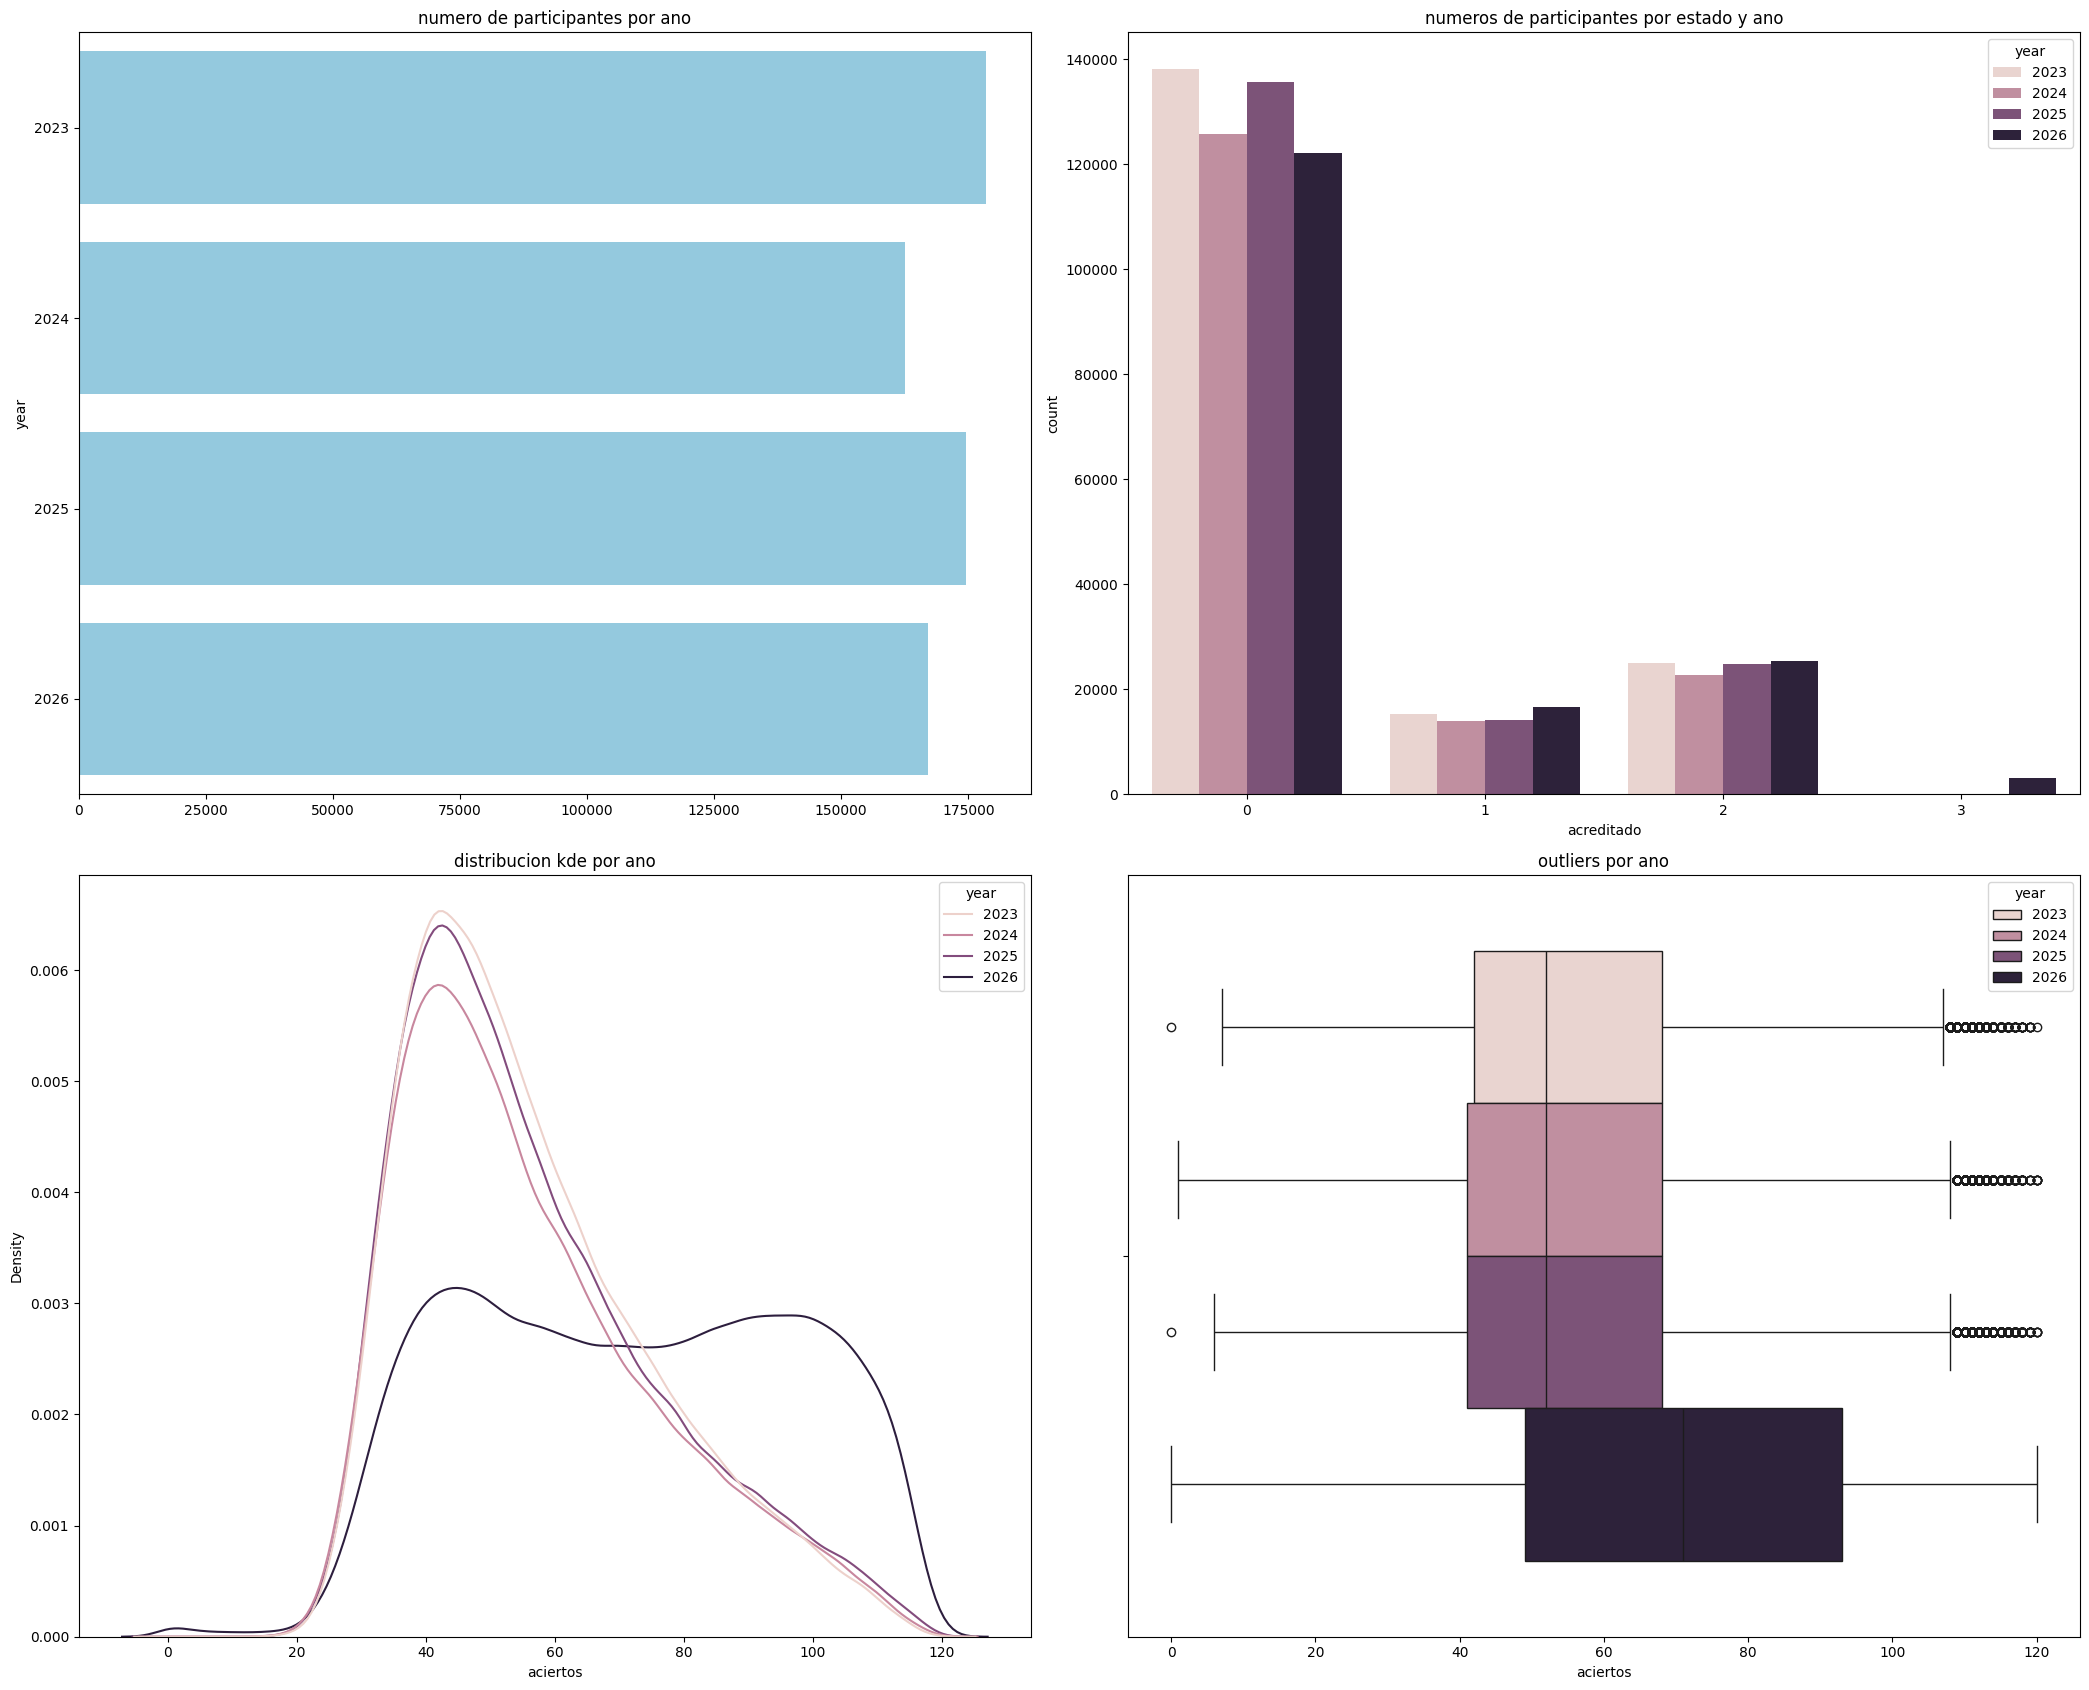

In [13]:
fig, ax = plt.subplots(2,2,figsize = (21,17))
ax= ax.flatten()

aspirantes_an = df_escolarizado.groupby('year').count()

ax[0].set_title('numero de participantes por ano')
sns.barplot(x=aspirantes_an['carrera'].values, y=aspirantes_an.index,orient='h',ax=ax[0],color='skyblue')

ax[1].set_title('numeros de participantes por estado y ano')
sns.countplot(data=df_escolarizado,x='acreditado',hue='year',ax = ax[1])

ax[2].set_title('distribucion kde por ano')
sns.kdeplot(data=df_escolarizado,x='aciertos',hue='year',ax=ax[2])

ax[3].set_title('outliers por ano')
sns.boxplot(data=df_escolarizado,x='aciertos',hue='year',ax=ax[3])


plt.tight_layout()
plt.show()

hagamos un kruscal para verificar que si hay un cambio significativamente estadisticamente y luego vemos el tamano del efecto

In [14]:
groups_year = []

for year, grupo in df_escolarizado.groupby("year"):
    aciertos_grupo = grupo["aciertos"].dropna()
    groups_year.append(aciertos_grupo)
epsilon , p_ = kruscal_effect(groups_year)

print(f'el efecto es {epsilon} y el p value es {p_}')

el efecto es 0.06597484350898078 y el p value es 0.0


como vimos en la celda anterior el p value da positivo gracias a la sensibilidad por eso nos enfocamos en epsilon que tiene un efecto mediano y en efecto, el ano explica al rededor del 6.6% de variacion de los rangos

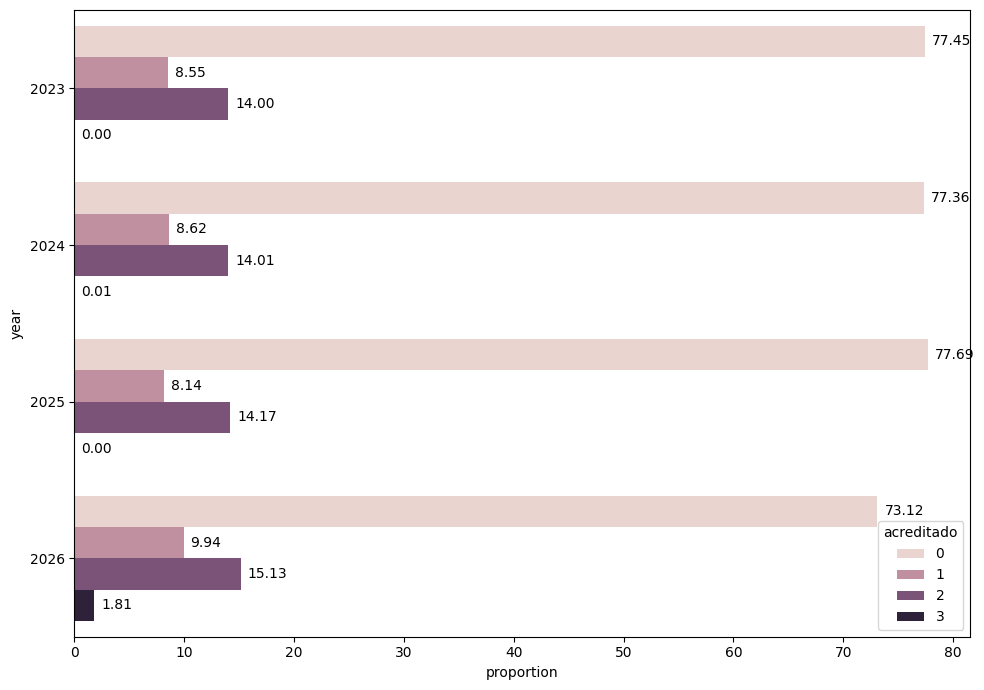

In [15]:
plt.figure(figsize=(10,7))
aspirantes_pct = df_escolarizado.groupby('year')['acreditado'].value_counts(normalize=True).reset_index(name='proportion')
aspirantes_pct['proportion'] = aspirantes_pct['proportion'].apply(lambda x : x*100)
ax = sns.barplot(data=aspirantes_pct, x='proportion', y='year', hue='acreditado', orient='h')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.tight_layout()
plt.show()

grafica1 : podemos ver que la parte de los participantes es un poco estable, el ultimo ano fueron menos pero no es una disminucion notoria

grafica2 : el segundo grafico podemos notar que las personas que no acreditaron son casi iguales a las del ano 24 que como vimos tiene incluso menos participantes que el 26 sin embargo hay una pequena diferencia en los que pasaron aunque no es tan notoria

grafica 3 y 4: aqui esta lo raro, podemos ver que practicamente la distribucion del 2026 es una bimodal, se deformo y hay un pico en los aciertos mas alto, cosa que no paso en anos pasados, incluso se notaba igual. el box plot da casi la misma informacion, se movio la media hacia arriba y por la dispercion no se dibujaron los outliers

grafica5: volvemos a ver la grafica 2 pero con porcentajes; entre 2025 y 2026 sube alrededor de 1.8 puntos porcentuales. No prueba algo irregular —puede depender de cupo, oferta o reglas pero tampoco es un cambio despreciable.

lo raro recae en los puntajes pero en si la acreditacion esta casi igual pero aun no podemos asumir nada

### por si solo todo esto es muy raro, sin embargo necesito profundizar mas para ver que esta pasando

se movio solo la ventana de puntajes o tambien cambio cuantos fueron aceptados?, mi hipotesis es que solo se movio la ventana de puntajes

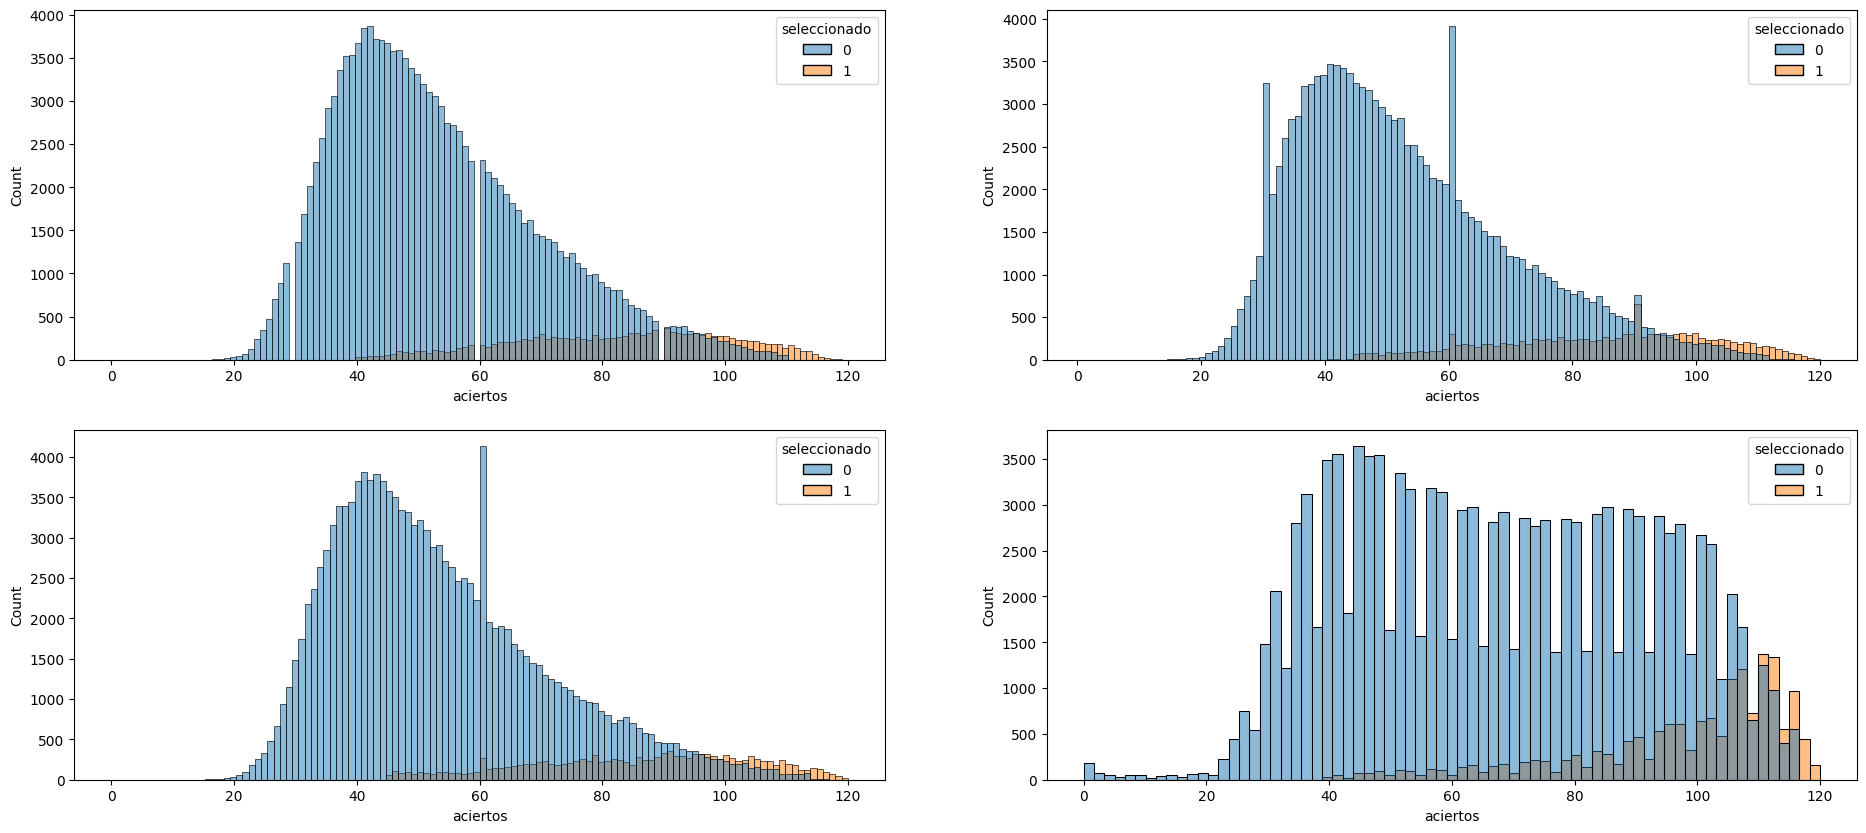

In [16]:
fig, ax = plt.subplots(2,2, figsize=(23,10))
for ax,d in zip(ax.flat,arr_year):
    sns.histplot(data=d, x='aciertos',ax=ax,hue='seleccionado')

la distribucion si cambio muy poco. comparemos d nuevo estadisticamente

In [17]:
pd.crosstab(df_escolarizado['year'],df_escolarizado['seleccionado'])

seleccionado,0,1
year,,
2023,163159,15245
2024,148463,14000
2025,160337,14206
2026,150477,16617


In [18]:
crammers(pd.crosstab(df_escolarizado['year'],df_escolarizado['seleccionado']))

(np.float64(0.02387337726303689), np.float64(5.3825221584046e-84))

podemos ver que si hay un cambio pero es minimo pero muy muy poquito, de hecho casi nada, podriamos hacer una prueba de cual esta jalando los datos pero dara 26, entonces la tasa no cambio, como suponia esto solo dice que se movio la ventana de puntajes

<Axes: ylabel='year'>

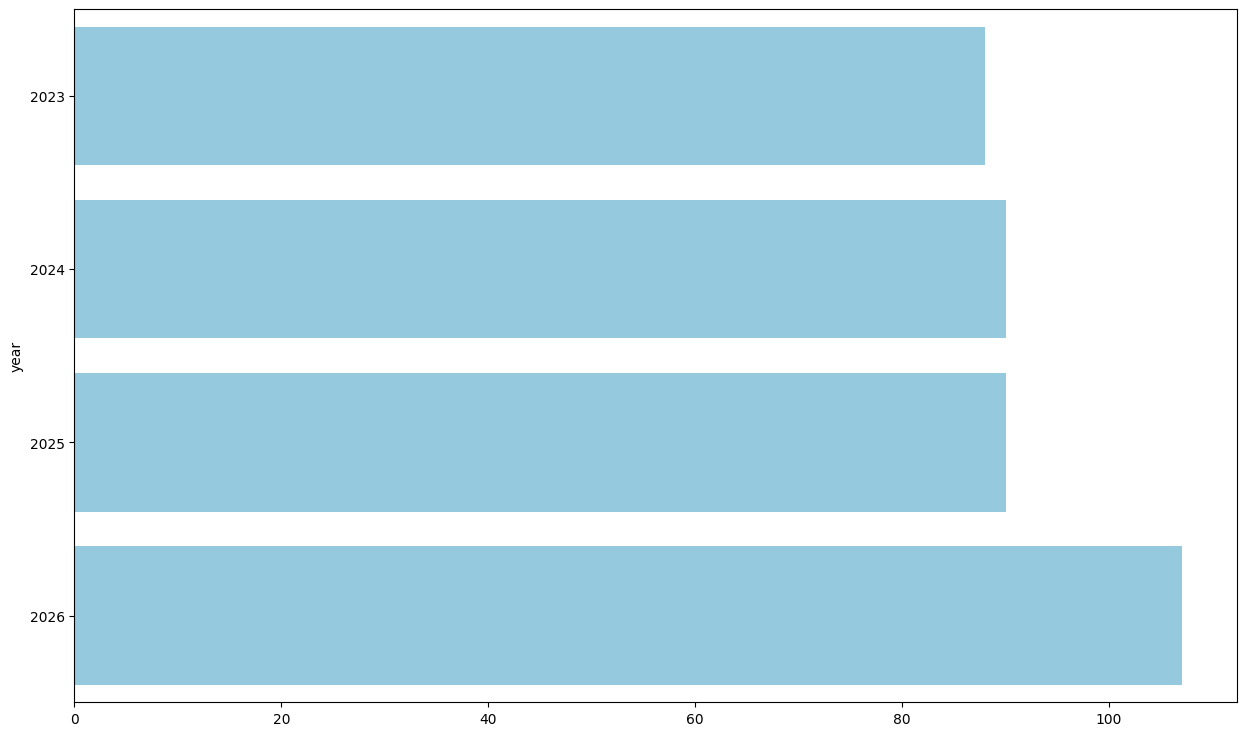

In [19]:
plt.figure(figsize=(15,9))
acierts_min_global_y = df_escolarizado.groupby('year')['aciertos_minimos'].median()
sns.barplot(x = acierts_min_global_y.values, y= acierts_min_global_y.index,orient='h',color='skyblue')

In [20]:
acierts_min_global_y

year
2023     88.0
2024     90.0
2025     90.0
2026    107.0
Name: aciertos_minimos, dtype: float64

podemos ver subio 17 puntos en general

esto es algo impresionante,

hasta ahora todo fue sin importar la carrera y la sede pero vamos por lo bueno

# POR CARRERA

vamos a analizar las carreras mas pedidas

<Axes: xlabel='count', ylabel='carrera'>

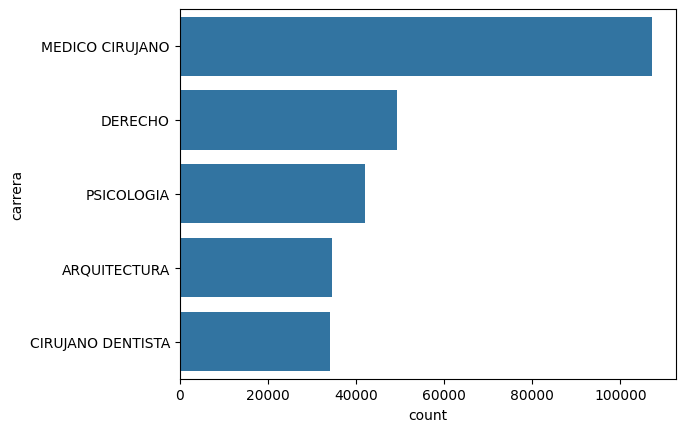

In [21]:
top5_=df_escolarizado['carrera'].value_counts().sort_values(ascending=False).head(5)
sns.barplot(top5_,orient='h')

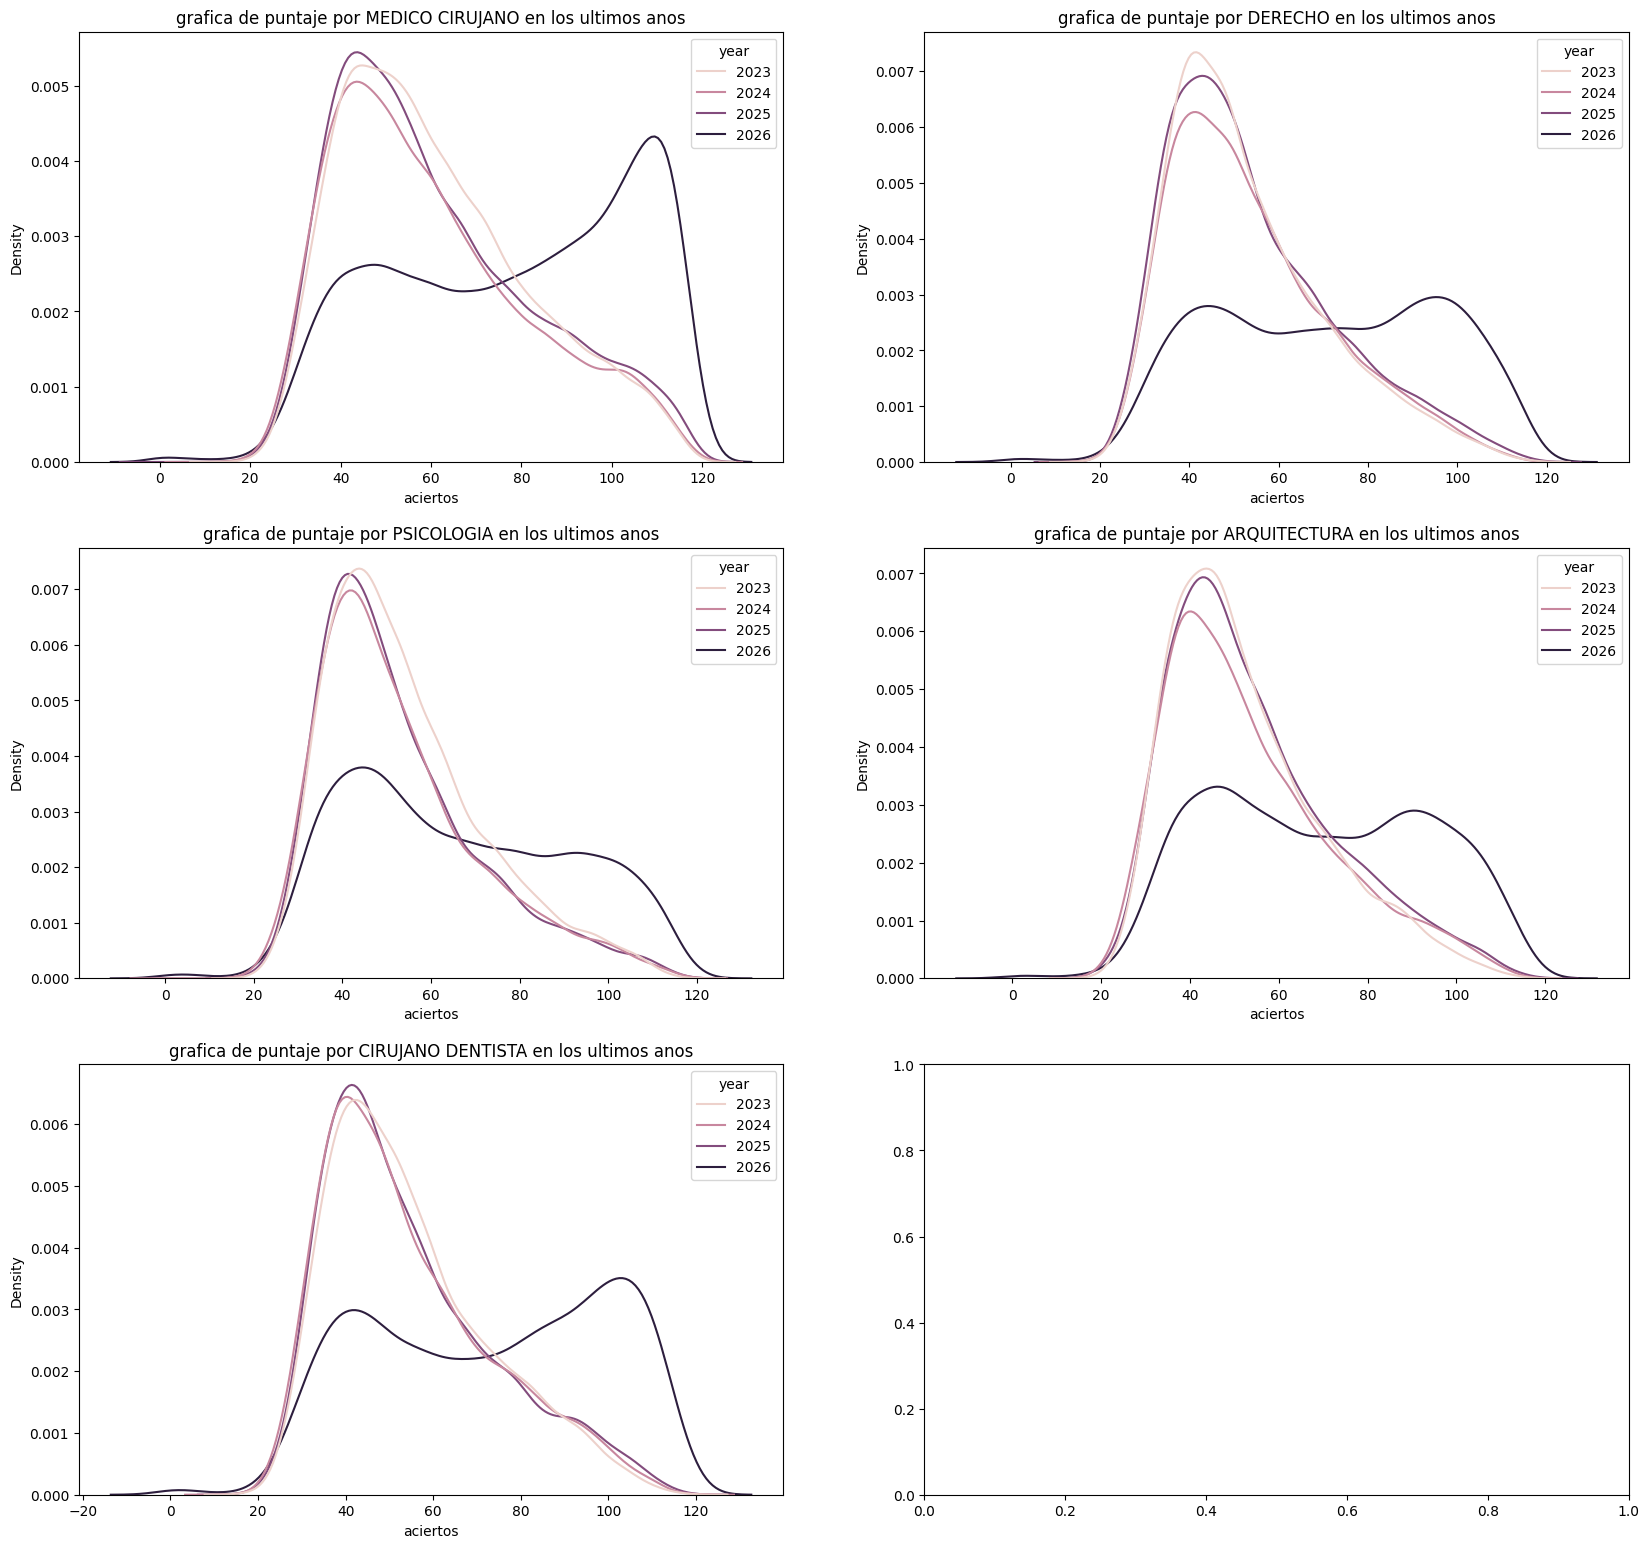

In [22]:
fig,ax = plt.subplots(3,2, figsize = (20,19))
ax =ax.flatten()
ruta_datos
for ax,carrera in zip(ax,top5_.index.to_list()):
    ax.set_title(f'grafica de puntaje por {carrera} en los ultimos anos')
    df_re = df_escolarizado[df_escolarizado['carrera'] == carrera]
    sns.kdeplot(data=df_re, x='aciertos',hue='year',ax=ax)

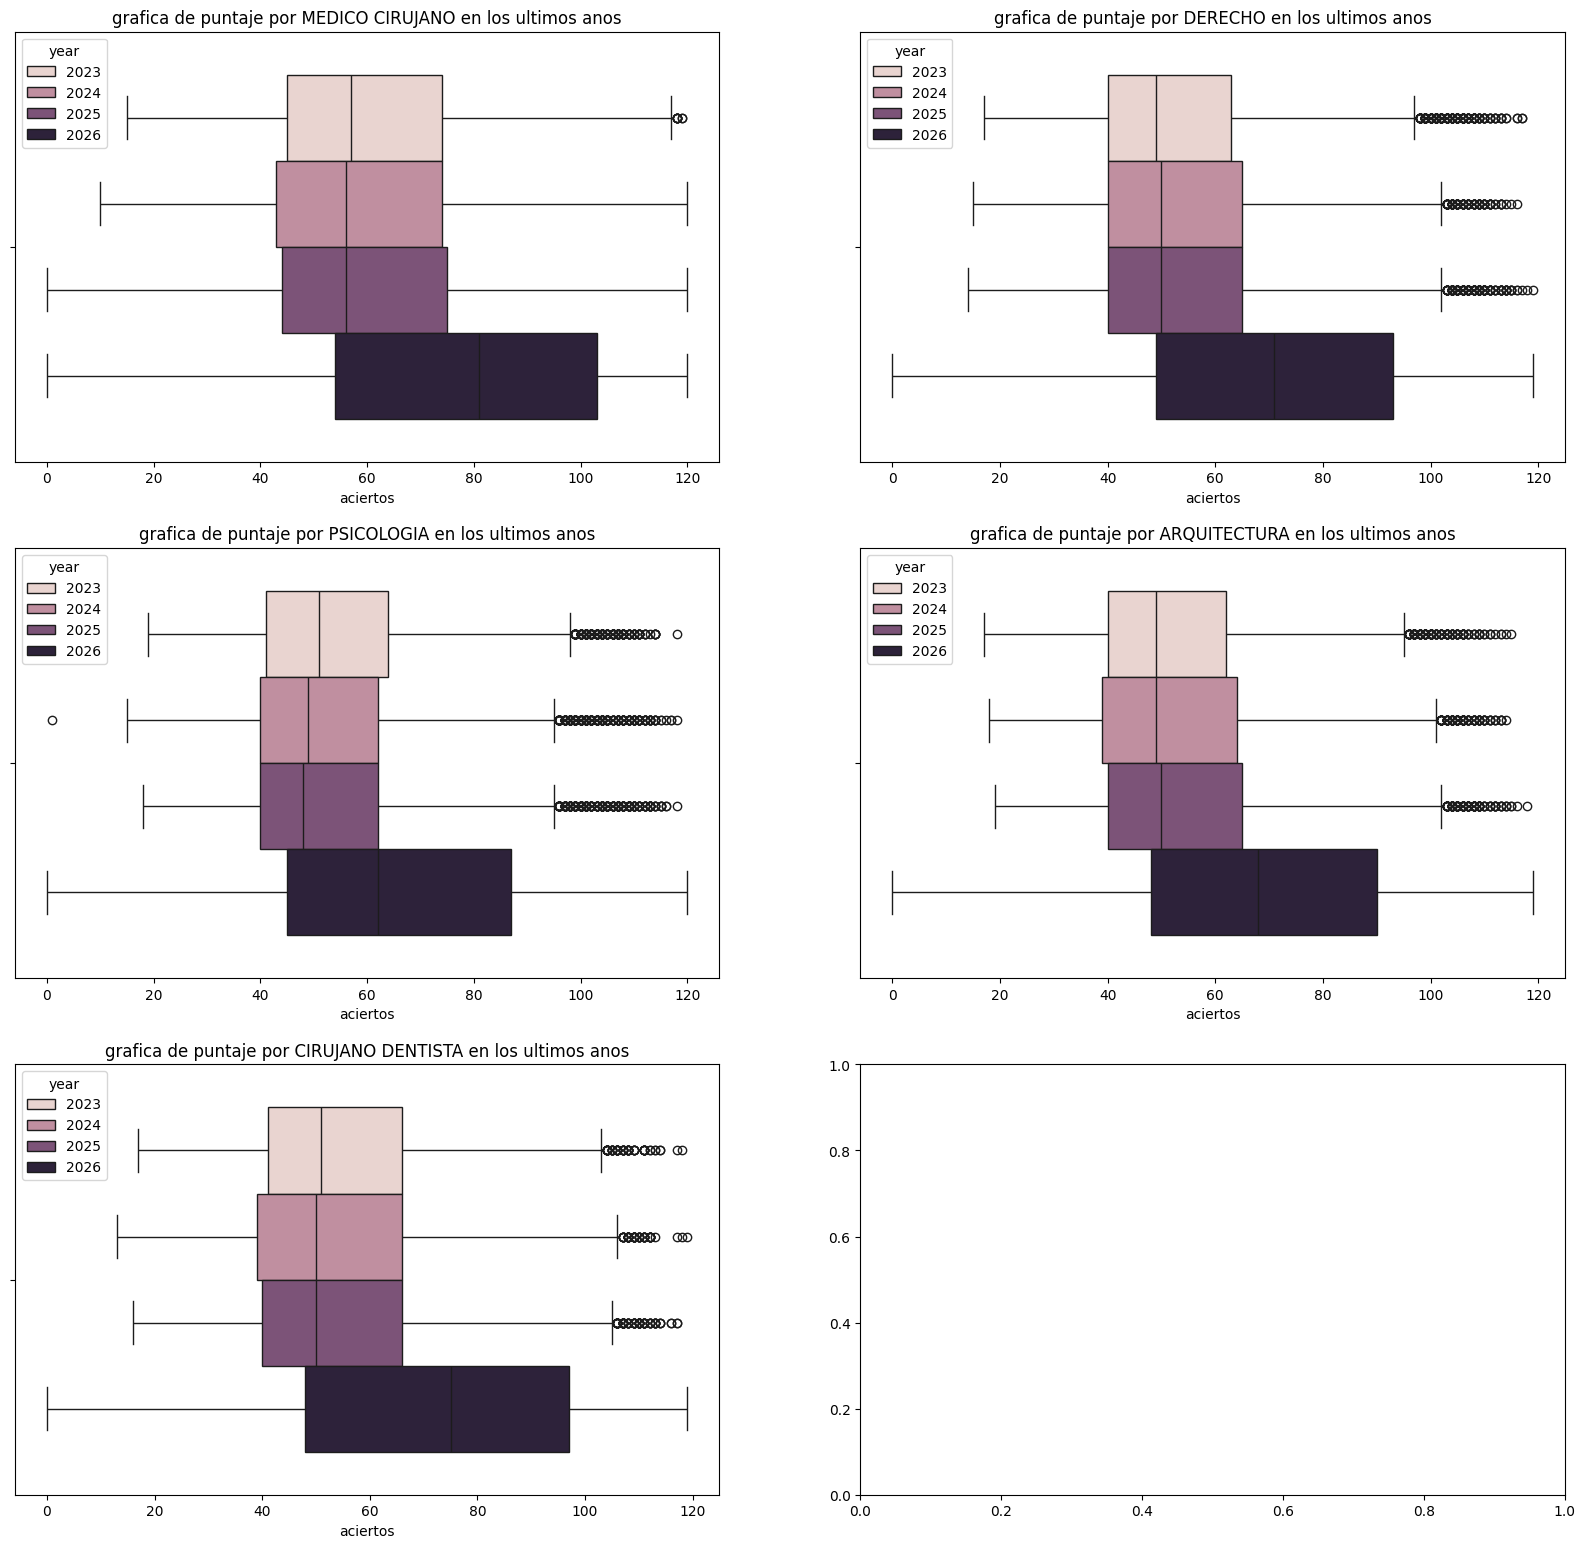

In [23]:
fig,ax = plt.subplots(3,2, figsize = (20,19))
ruta_datos
for ax,carrera in zip(ax.flat,top5_.index.to_list()):
    ax.set_title(f'grafica de puntaje por {carrera} en los ultimos anos')
    df_re = df_escolarizado[df_escolarizado['carrera'] == carrera]
    sns.boxplot(data=df_re, x='aciertos',hue='year',ax=ax)

todas tienen un cambio muy brusco en el 2026 pero sobre todo en medico cirujano y es una anomalia

hare un analisis automatico

# 2026 vs 2025

es mas facil para mi jaja

In [24]:
df_escolarizado_2526 = df_escolarizado[df_escolarizado['year'].isin([2025,2026])].dropna(subset=('aciertos'))

In [25]:
umbrales = [90,100,110]

resultados = [ ]

for u in umbrales:
    pct_26 = (df_escolarizado_2526.loc[df_escolarizado_2526['year']==2026,'aciertos']>=u).mean()*100
    pct_25 = (df_escolarizado_2526.loc[df_escolarizado_2526['year']==2025,'aciertos']>=u).mean()*100
    diferencia = (pct_26-pct_25)
    aumento_rel = ((pct_26-pct_25)/pct_25)*100
    vez_mayor = 1 + (aumento_rel/100)
    
    resultados.append({
        'prob_mayor_umbral_25':pct_25,
        'prob_mayor_umbral_26':pct_26,
        'diferencia': diferencia,
        'aumento relativo' : aumento_rel,
        'veces_mayor': round(vez_mayor,2)
    })
    
outliers = pd.DataFrame(resultados)
outliers.rename(index={0:90,1:100,2:110},inplace=True)
outliers

,prob_mayor_umbral_25,prob_mayor_umbral_26,diferencia,aumento relativo,veces_mayor
90,8.143449,29.107120,20.963671,257.429880,3.57
100,3.716047,16.992760,13.276714,357.280600,4.57
110,0.964312,5.789489,4.825177,500.375221,6.00


Text(0, 0.5, 'outliers')

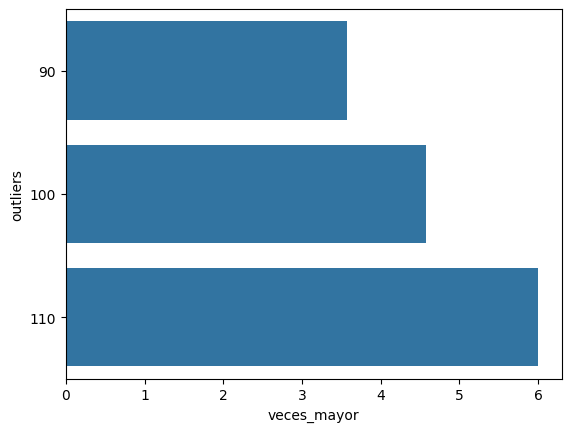

In [26]:
sns.barplot(data=outliers,x='veces_mayor',y=outliers.index,orient='h')
plt.ylabel('outliers')

Mientras más extremo era el puntaje bajo el patrón de 2025, más aumentó en 2026. Estadísticamente eso se describe como una cola derecha más pesada: hay una concentración desproporcionada de resultados muy altos, como los vimos en los anteriores

<Axes: xlabel='margen_sobre_minimo', ylabel='Density'>

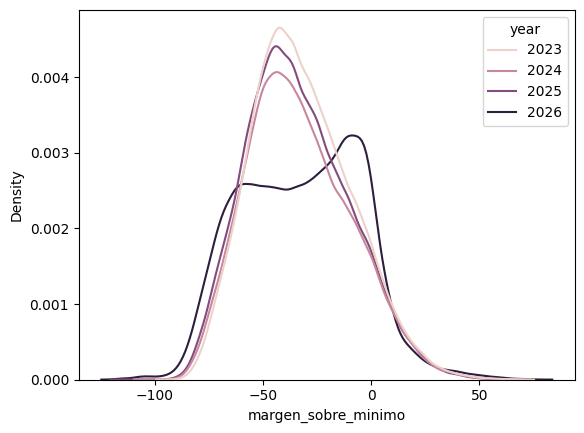

In [27]:
sns.kdeplot(data=df_escolarizado,x='margen_sobre_minimo', hue='year')

In [28]:
presentaron = df_escolarizado.dropna(subset=['margen_sobre_minimo']).copy()

for limite in [-20, -10, 0, 10]:
    resultado = (
        (presentaron['margen_sobre_minimo'] >= limite)
        .groupby(presentaron['year'])
        .mean()
        .mul(100)
    )
    
    print(f'\nPorcentaje con margen ≥ {limite}:')
    print(resultado)


Porcentaje con margen ≥ -20:
year
2023    29.631689
2024    28.556557
2025    27.969726
2026    38.108897
Name: margen_sobre_minimo, dtype: float64

Porcentaje con margen ≥ -10:
year
2023    18.423394
2024    18.190042
2025    17.464014
2026    25.385460
Name: margen_sobre_minimo, dtype: float64

Porcentaje con margen ≥ 0:
year
2023     9.972524
2024    10.051334
2025     9.506602
2026    12.005982
Name: margen_sobre_minimo, dtype: float64

Porcentaje con margen ≥ 10:
year
2023    4.651969
2024    4.693973
2025    4.335722
2026    4.637805
Name: margen_sobre_minimo, dtype: float64


# POR SEDE

<Axes: title={'center': 'las sedes mas pedidas'}, xlabel='count', ylabel='plantel'>

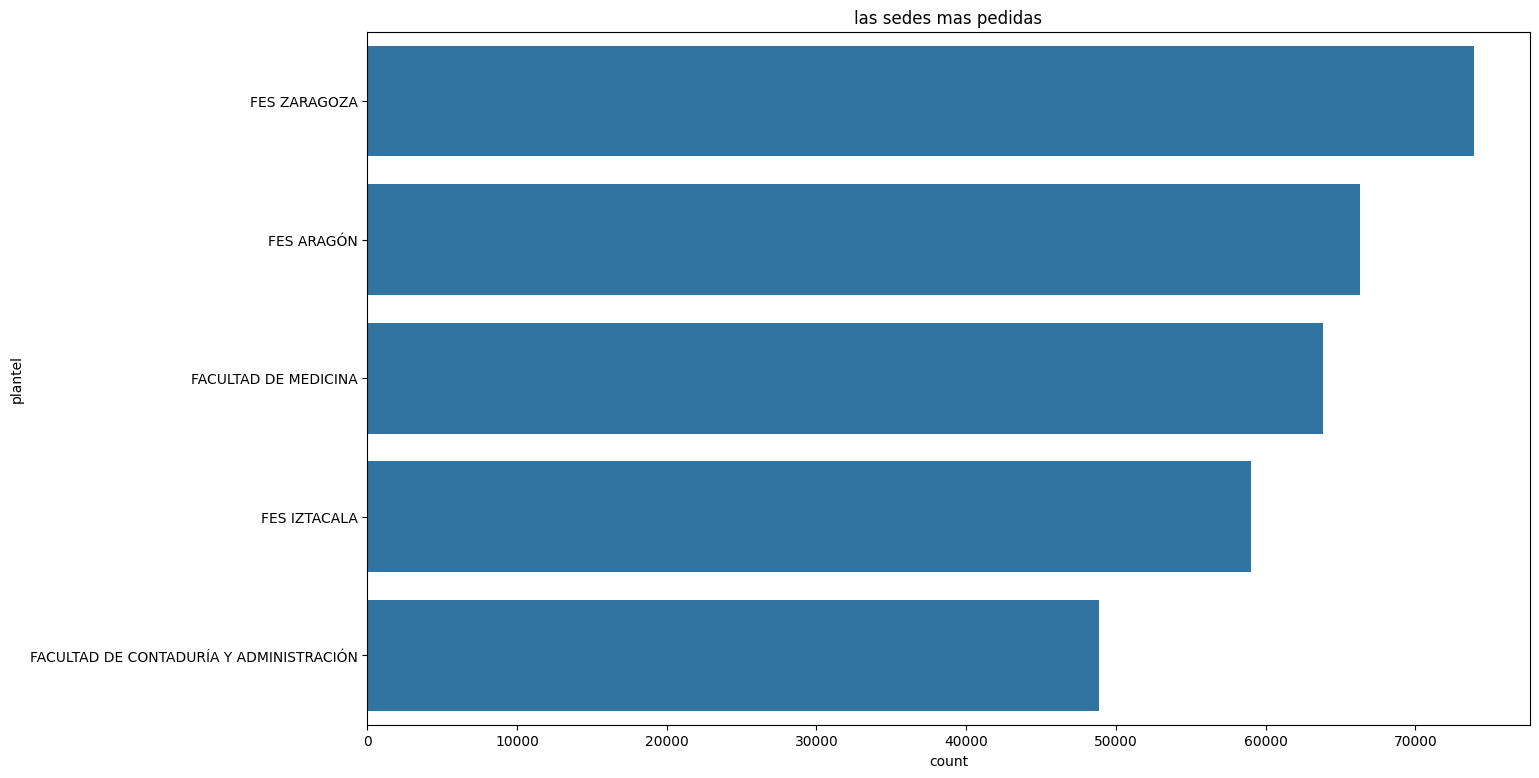

In [29]:
plt.figure(figsize=(15,9))
plt.title('las sedes mas pedidas')
top5_sedes=df_escolarizado['plantel'].value_counts().sort_values(ascending=False).head(5)
sns.barplot(top5_sedes,orient='h')

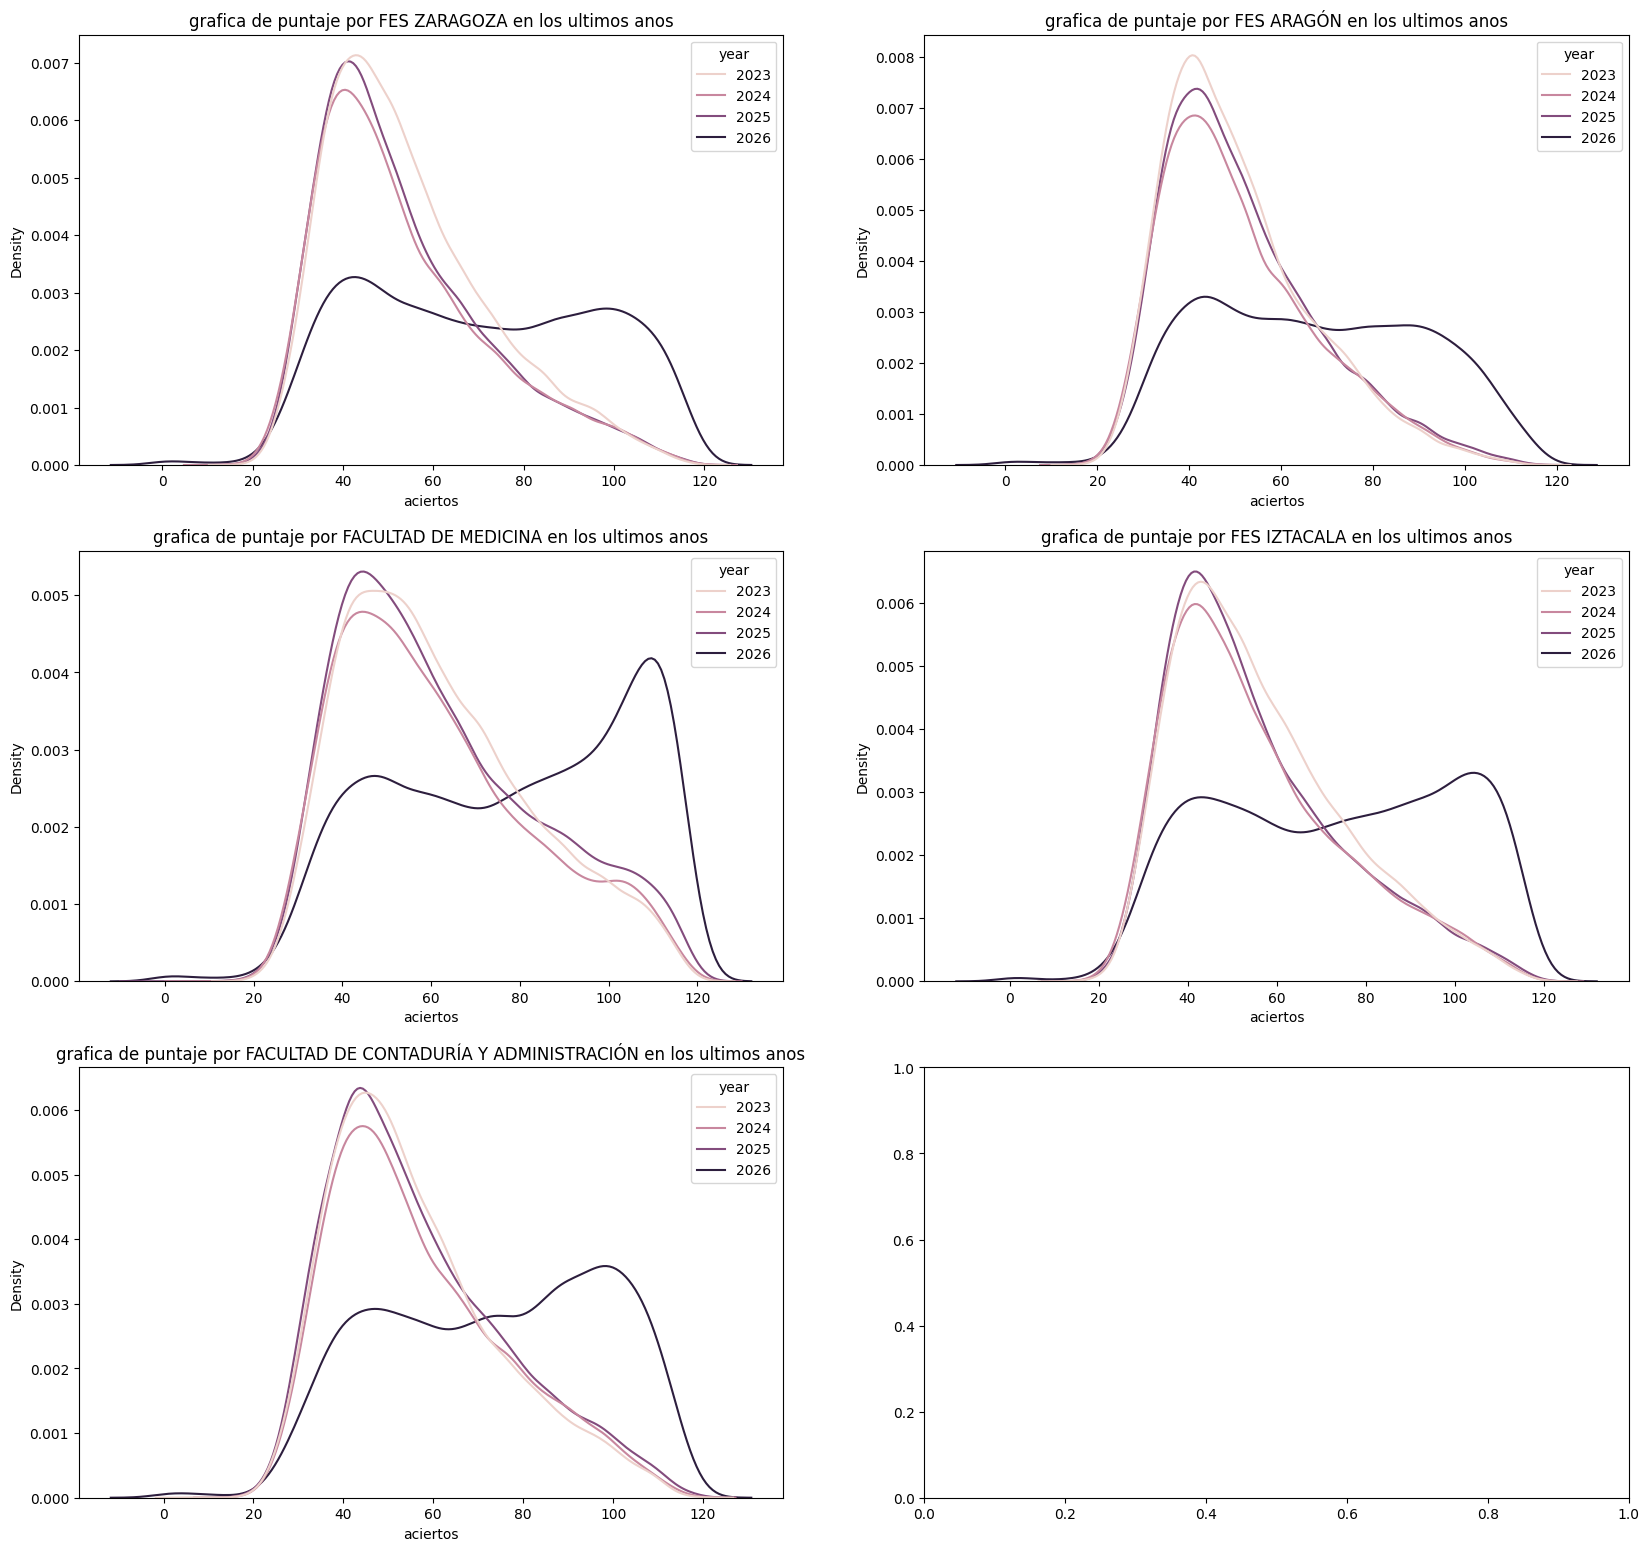

In [30]:
fig,ax = plt.subplots(3,2, figsize = (20,19))
ax =ax.flatten()
ruta_datos
for ax,sede in zip(ax,top5_sedes.index.to_list()):
    ax.set_title(f'grafica de puntaje por {sede} en los ultimos anos')
    df_re = df_escolarizado[df_escolarizado['plantel'] == sede]
    sns.kdeplot(data=df_re, x='aciertos',hue='year',ax=ax)

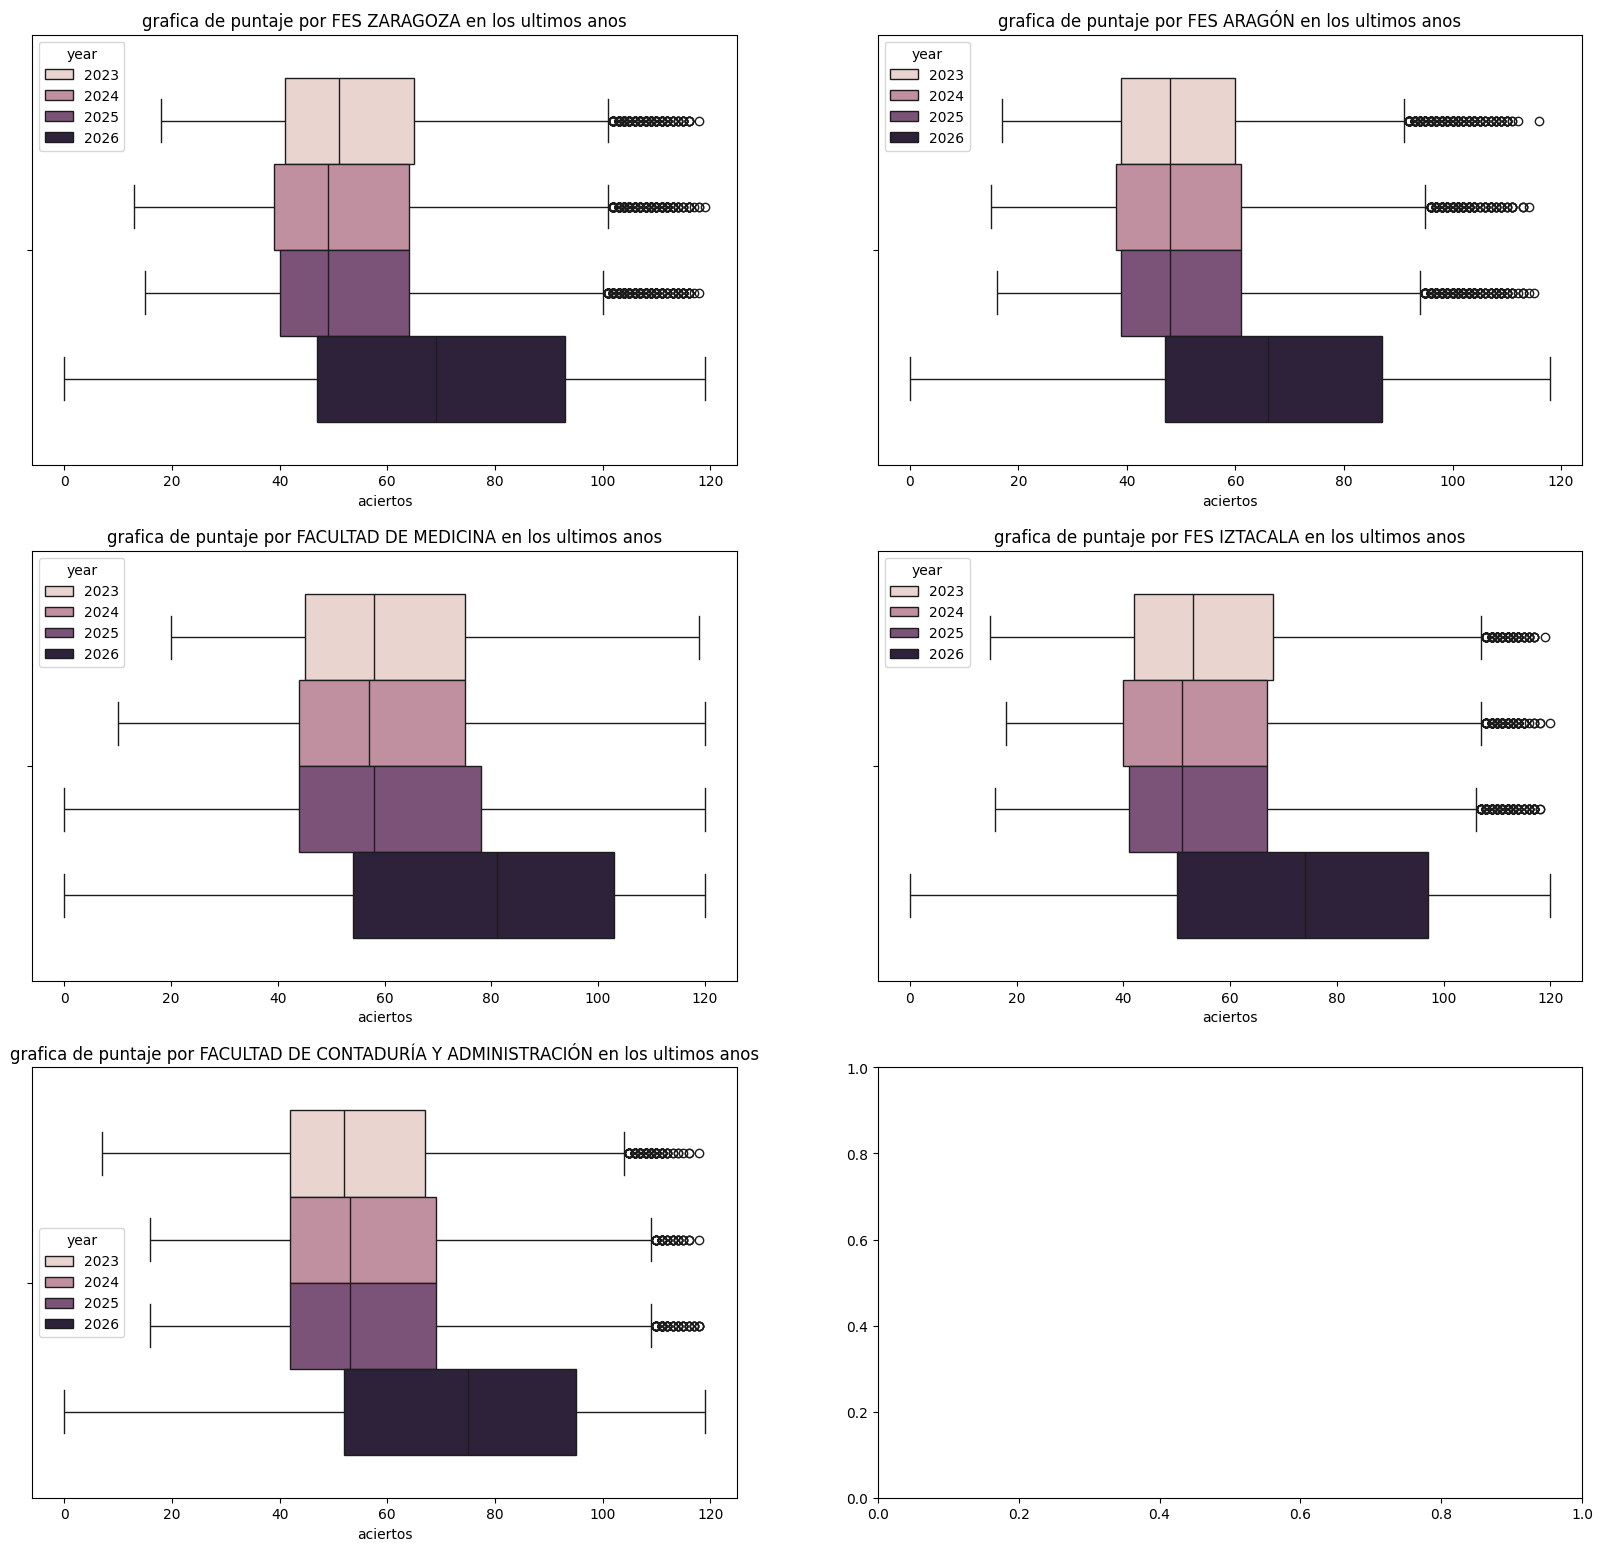

In [31]:
fig,ax = plt.subplots(3,2, figsize = (20,19))
ruta_datos
for ax,sede in zip(ax.flat,top5_sedes.index.to_list()):
    ax.set_title(f'grafica de puntaje por {sede} en los ultimos anos')
    df_re = df_escolarizado[df_escolarizado['plantel'] == sede]
    sns.boxplot(data=df_re, x='aciertos',hue='year',ax=ax)

la verdad no es raro, las sedes reflejan las carreras, la facultad de medicina cambio mucho, se comportaba como otras carreras en anos anterores y ahora esa facultad ahora tiene casi otro pico

## GMM CON SELECCION DE COMPONENTES

En K-Means se suele mirar la inercia. Para un Gaussian Mixture Model es mas apropiado comparar el BIC: el valor mas bajo indica el equilibrio preferido entre ajuste y complejidad. La funcion prueba de 1 a 4 componentes y grafica la seleccion junto con los grupos.

In [32]:
def gmm_simple(df, titulo, max_componentes=4):
    datos = df.dropna(subset=['aciertos']).copy()
    X = datos[['aciertos']].to_numpy()
    modelos = []
    resultados = []

    for k in range(1, max_componentes + 1):
        modelo = GaussianMixture(
            n_components=k, random_state=42, n_init=3, max_iter=500
        ).fit(X)
        modelos.append(modelo)
        resultados.append({'componentes': k, 'BIC': modelo.bic(X)})

    tabla_bic = pd.DataFrame(resultados)
    mejor_posicion = tabla_bic['BIC'].idxmin()
    mejor_modelo = modelos[mejor_posicion]
    mejor_k = int(tabla_bic.loc[mejor_posicion, 'componentes'])

    etiquetas = mejor_modelo.predict(X)
    orden = np.argsort(mejor_modelo.means_.ravel())
    mapa = {int(etiqueta): posicion for posicion, etiqueta in enumerate(orden)}
    datos['grupo_gmm'] = pd.Series(etiquetas, index=datos.index).map(mapa).astype(int)

    resumen = pd.DataFrame({
        'grupo_gmm': range(mejor_k),
        'media_estimada': mejor_modelo.means_.ravel()[orden],
        'peso_estimado': mejor_modelo.weights_.ravel()[orden]
    })

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    sns.lineplot(data=tabla_bic, x='componentes', y='BIC', marker='o', ax=ax[0])
    ax[0].scatter(mejor_k, tabla_bic.loc[mejor_posicion, 'BIC'], color='red', s=90, zorder=3)
    ax[0].set_xticks(range(1, max_componentes + 1))
    ax[0].set_title(f'BIC: se eligen {mejor_k} componentes')

    sns.histplot(data=datos, x='aciertos', hue='grupo_gmm', bins=40, palette='viridis', ax=ax[1])
    ax[1].set_title(f'GMM elegido - {titulo}')
    plt.tight_layout()

    return datos, tabla_bic, resumen


# ANALIZANDO LA CARRERA DE MEDICO CIRUJANO

en esta parte aplicare varias pruebas estadistcias intentando encontrar un patron o si es general: ojo, esto solo es en medico cirujano

<Axes: title={'center': 'puntajes de medico cirujano 2026'}, xlabel='aciertos', ylabel='Count'>

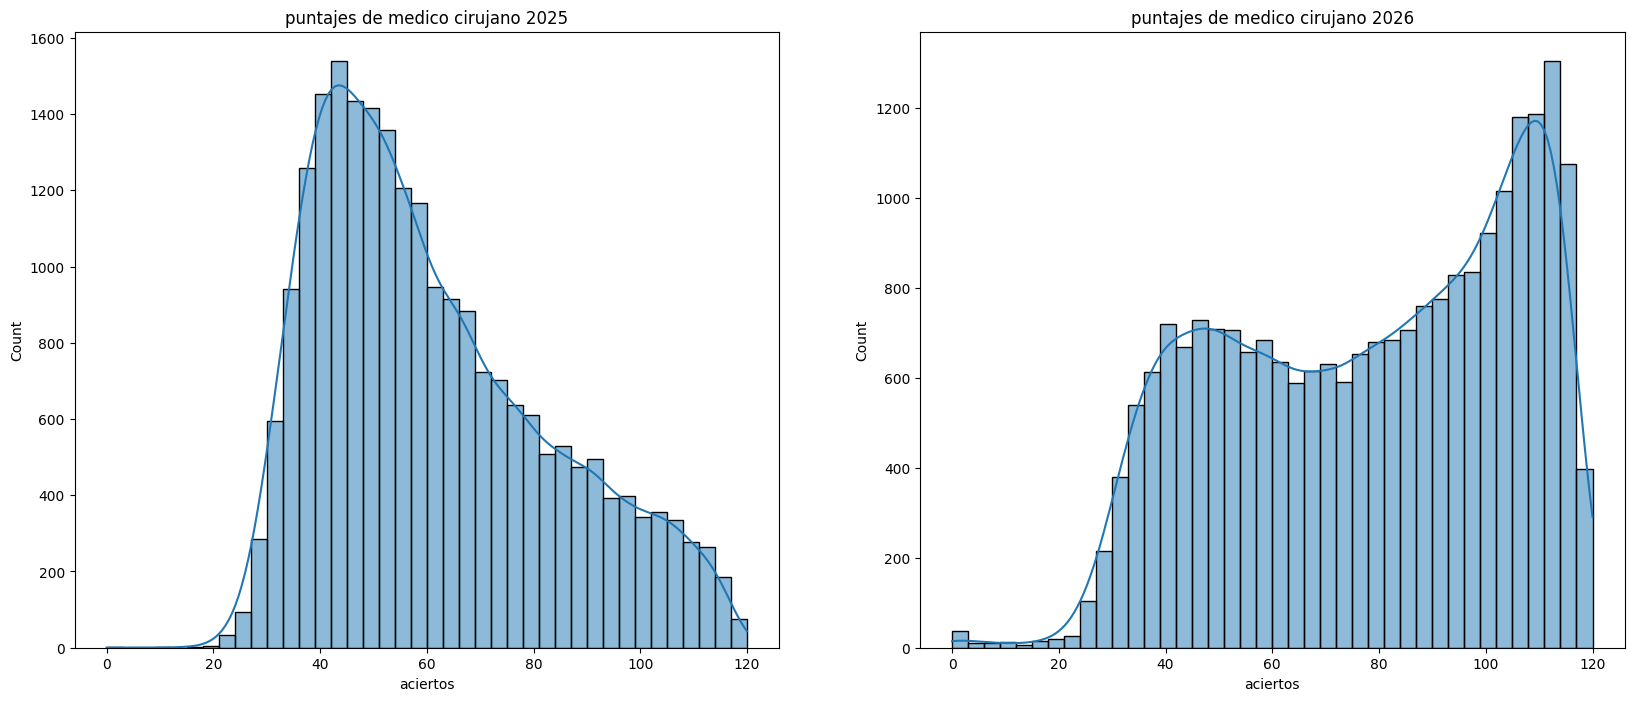

In [33]:
fig, ax = plt.subplots(1,2,figsize = (20,8))
ax = ax.flatten()
df_escolarizado_2025_m = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'MEDICO CIRUJANO') & (df_escolarizado_2526['year'] == 2025)].dropna(subset=['aciertos'])

df_escolarizado_2026_m = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'MEDICO CIRUJANO') & (df_escolarizado_2526['year'] == 2026)].dropna(subset=['aciertos'])

ax[0].set_title('puntajes de medico cirujano 2025')
sns.histplot(data=df_escolarizado_2025_m,x='aciertos',kde=True,bins=40,ax=ax[0])

ax[1].set_title('puntajes de medico cirujano 2026')
sns.histplot(data=df_escolarizado_2026_m,x='aciertos',kde=True,bins=40,ax=ax[1])

In [34]:
describe_e2025 = df_escolarizado_2025_m.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']
describe_e2026=df_escolarizado_2026_m.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']

tabla_aR = pd.DataFrame({
    '2025':describe_e2025,
    '2026': describe_e2026
})

tabla_aR

,2025,2026
count,22837.000000,22933.000000
mean,60.942506,78.077269
std,21.951576,26.917059
min,0.000000,0.000000
25%,44.000000,54.000000
50%,56.000000,81.000000
75%,75.000000,103.000000
90%,95.000000,112.000000
99%,114.000000,118.000000
max,120.000000,120.000000


aqui volvemos a notar que hay diferencia 

## PRUEBA DE MEDIAS CON MANN-WHINEY

In [35]:
delta,p = delta_clip(df_escolarizado_2026_m['aciertos'],df_escolarizado_2025_m['aciertos'])
delta,p

(np.float64(0.37077331306381023), np.float64(0.0))

el tamano del efecto es mediano: Hay un cambio claro en el nivel de exigencia o en la preparación de los aspirantes entre generaciones

In [36]:
medico = df_escolarizado[
    (df_escolarizado['carrera'] == 'MEDICO CIRUJANO') &
    df_escolarizado['aciertos'].notna()
].copy()

medico.groupby(['year', 'plantel'])['aciertos'].agg(
    n='count',
    promedio='mean',
    mediana='median',
    desviacion='std',
    sesgo='skew',
    minimo='min',
    maximo='max'
)

n   promedio  mediana  desviacion     sesgo  \
year plantel                                                                 
2023 FACULTAD DE MEDICINA  13275  61.763465     58.0   20.837832  0.591953   
     FES IZTACALA           5420  61.396310     58.0   20.562467  0.538204   
     FES ZARAGOZA           4443  58.360117     54.0   19.971072  0.746654   
2024 FACULTAD DE MEDICINA  12458  61.158131     57.0   21.727228  0.634232   
     FES IZTACALA           5031  60.015703     56.0   21.198990  0.630612   
     FES ZARAGOZA           3932  56.092065     51.0   20.593908  0.857152   
2025 FACULTAD DE MEDICINA  13626  62.452811     58.0   22.536807  0.614600   
     FES IZTACALA           5272  60.228566     56.0   21.128006  0.665422   
     FES ZARAGOZA           3939  56.673521     52.0   20.315504  0.852801   
2026 FACULTAD DE MEDICINA  13144  78.107197     81.0   27.034604 -0.264634   
     FES IZTACALA           5521  79.465314     84.0   26.416973 -0.397232   
     FES ZARAGOZA           4268  76.189550     79.0   27.088332 -0.197830   

                           minimo  maximo  
year plantel                               
2023 FACULTAD DE MEDICINA    20.0   119.0  
     FES IZTACALA            15.0   119.0  
     FES ZARAGOZA            21.0   118.0  
2024 FACULTAD DE MEDICINA    10.0   120.0  
     FES IZTACALA            18.0   120.0  
     FES ZARAGOZA            19.0   118.0  
2025 FACULTAD DE MEDICINA     0.0   120.0  
     FES IZTACALA            19.0   118.0  
     FES ZARAGOZA            15.0   117.0  
2026 FACULTAD DE MEDICINA     0.0   120.0  
     FES IZTACALA             0.0   120.0  
     FES ZARAGOZA             0.0   119.0

<Axes: xlabel='aciertos', ylabel='Proportion'>

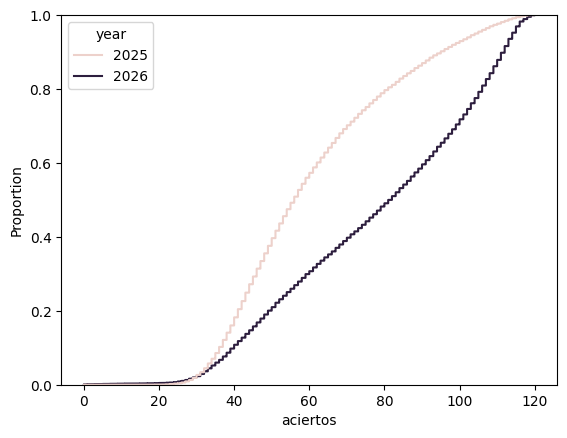

In [37]:
sns.ecdfplot(
    data=medico[medico['year'].isin([2025, 2026])],
    x='aciertos',
    hue='year'
)

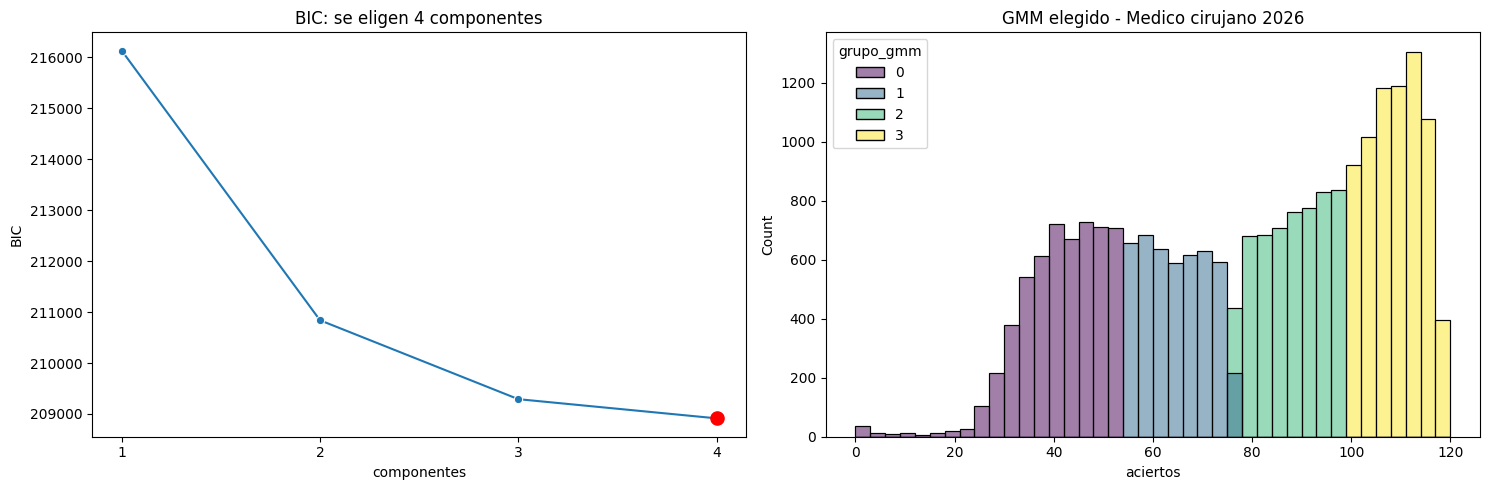

In [38]:
df_escolarizado_2026_m, bic_m, resumen_gmm_m = gmm_simple(
    df_escolarizado_2026_m, 'Medico cirujano 2026'
)

In [39]:
display(bic_m)
display(resumen_gmm_m)

,componentes,BIC
0,1,216125.856290
1,2,210837.988844
2,3,209290.607458
3,4,208914.565472


,grupo_gmm,media_estimada,peso_estimado
0,0,42.097773,0.242744
1,1,64.061622,0.202897
2,2,87.663273,0.246864
3,3,108.032546,0.307495


# DERECHO

<Axes: title={'center': 'puntajes de derecho 2026'}, xlabel='aciertos', ylabel='Count'>

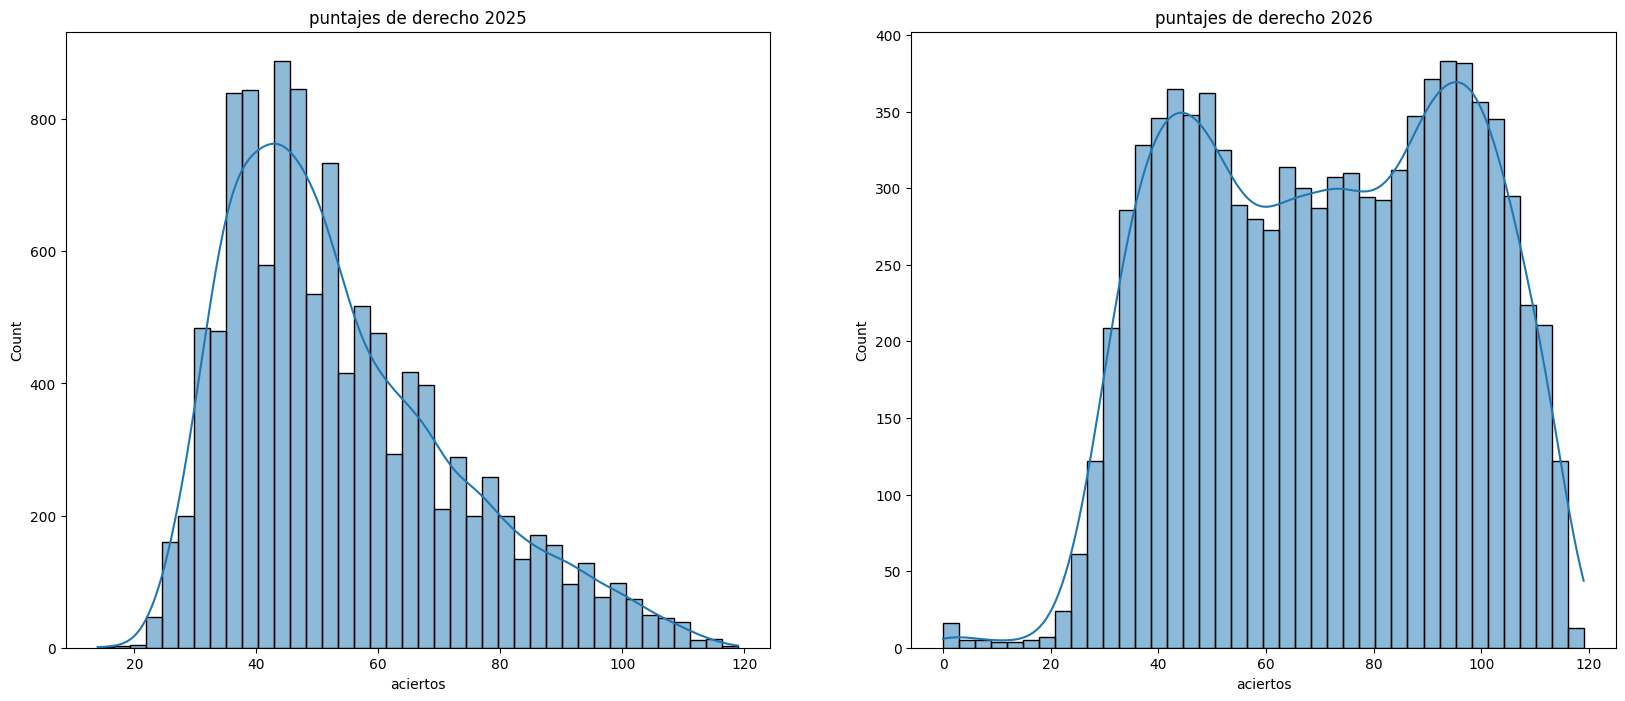

In [40]:
fig, ax = plt.subplots(1,2,figsize = (20,8))
ax = ax.flatten()
df_escolarizado_2025_d = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'DERECHO') & (df_escolarizado_2526['year'] == 2025)].dropna(subset=['aciertos'])

df_escolarizado_2026_d = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'DERECHO') & (df_escolarizado_2526['year'] == 2026)].dropna(subset=['aciertos'])

ax[0].set_title('puntajes de derecho 2025')
sns.histplot(data=df_escolarizado_2025_d,x='aciertos',kde=True,bins=40,ax=ax[0])

ax[1].set_title('puntajes de derecho 2026')
sns.histplot(data=df_escolarizado_2026_d,x='aciertos',kde=True,bins=40,ax=ax[1])

In [41]:
describe_d2025 = df_escolarizado_2025_d.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']
describe_d2026=df_escolarizado_2026_d.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']

tabla_aR = pd.DataFrame({
    '2025':describe_d2025,
    '2026': describe_d2026
})

tabla_aR

,2025,2026
count,11415.000000,9129.000000
mean,53.981428,70.817066
std,18.676087,25.181751
min,14.000000,0.000000
25%,40.000000,49.000000
50%,50.000000,71.000000
75%,65.000000,93.000000
90%,82.000000,104.000000
99%,105.000000,115.000000
max,119.000000,119.000000


In [42]:
delta,p = delta_clip(df_escolarizado_2026_d['aciertos'],df_escolarizado_2025_d['aciertos'])
delta,p

(np.float64(0.39120848602742586), np.float64(0.0))

In [43]:
der = df_escolarizado[
    (df_escolarizado['carrera'] == 'DERECHO') &
    df_escolarizado['aciertos'].notna()
].copy()

der.groupby(['year', 'plantel'])['aciertos'].agg(
    n='count',
    promedio='mean',
    mediana='median',
    desviacion='std',
    sesgo='skew',
    minimo='min',
    maximo='max'
)

n   promedio  mediana  \
year plantel                                                                  
2023 FACULTAD DE DERECHO                           5536  55.872110     52.0   
     FES ACATLÁN                                   2100  49.942857     47.0   
     FES ARAGÓN                                    3368  50.546912     47.0   
2024 FACULTAD DE DERECHO                           5260  56.811597     53.0   
     FES ACATLÁN                                   1957  50.563107     47.0   
     FES ARAGÓN                                    3234  51.645949     48.0   
2025 FACULTAD DE DERECHO                           6089  56.966825     52.0   
     FES ACATLÁN                                   2083  50.461834     47.0   
     FES ARAGÓN                                    3243  50.636756     47.0   
2026 ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD MORELIA    94  62.234043     61.0   
     FACULTAD DE DERECHO                           4935  72.938197     74.0   
     FES ACATLÁN                                   1623  68.351818     68.0   
     FES ARAGÓN                                    2477  68.532095     69.0   

                                                   desviacion     sesgo  \
year plantel                                                              
2023 FACULTAD DE DERECHO                            18.725968  0.773628   
     FES ACATLÁN                                    15.441866  0.946810   
     FES ARAGÓN                                     15.877394  0.908786   
2024 FACULTAD DE DERECHO                            19.326157  0.695712   
     FES ACATLÁN                                    16.146623  0.875010   
     FES ARAGÓN                                     16.421543  0.734087   
2025 FACULTAD DE DERECHO                            20.011935  0.699500   
     FES ACATLÁN                                    16.189555  0.993811   
     FES ARAGÓN                                     16.484772  0.957898   
2026 ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD MORELIA   22.905803  0.211310   
     FACULTAD DE DERECHO                            25.528361 -0.144410   
     FES ACATLÁN                                    24.454645 -0.010658   
     FES ARAGÓN                                     24.630178 -0.024831   

                                                   minimo  maximo  
year plantel                                                       
2023 FACULTAD DE DERECHO                             19.0   117.0  
     FES ACATLÁN                                     20.0   113.0  
     FES ARAGÓN                                      17.0   116.0  
2024 FACULTAD DE DERECHO                             15.0   116.0  
     FES ACATLÁN                                     22.0   107.0  
     FES ARAGÓN                                      18.0   109.0  
2025 FACULTAD DE DERECHO                             14.0   119.0  
     FES ACATLÁN                                     17.0   114.0  
     FES ARAGÓN                                      21.0   113.0  
2026 ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD MORELIA     3.0   116.0  
     FACULTAD DE DERECHO                              0.0   119.0  
     FES ACATLÁN                                      1.0   117.0  
     FES ARAGÓN                                       0.0   118.0

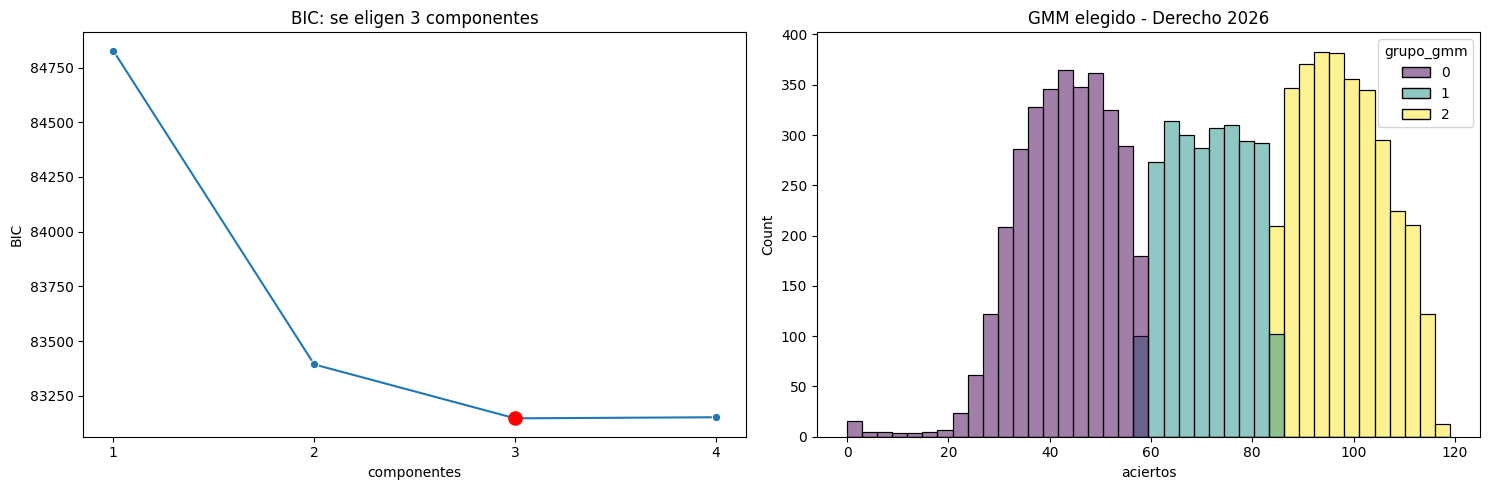

In [44]:
df_escolarizado_2026_d, bic_d, resumen_gmm_d = gmm_simple(
    df_escolarizado_2026_d, 'Derecho 2026'
)

In [45]:
display(bic_d)
display(resumen_gmm_d)

,componentes,BIC
0,1,84826.708844
1,2,83393.126463
2,3,83146.797872
3,4,83151.829331


,grupo_gmm,media_estimada,peso_estimado
0,0,43.376823,0.357419
1,1,71.683553,0.293433
2,2,98.179045,0.349149


# PSICOLOGIA

<Axes: title={'center': 'puntajes de psicologia 2026'}, xlabel='aciertos', ylabel='Count'>

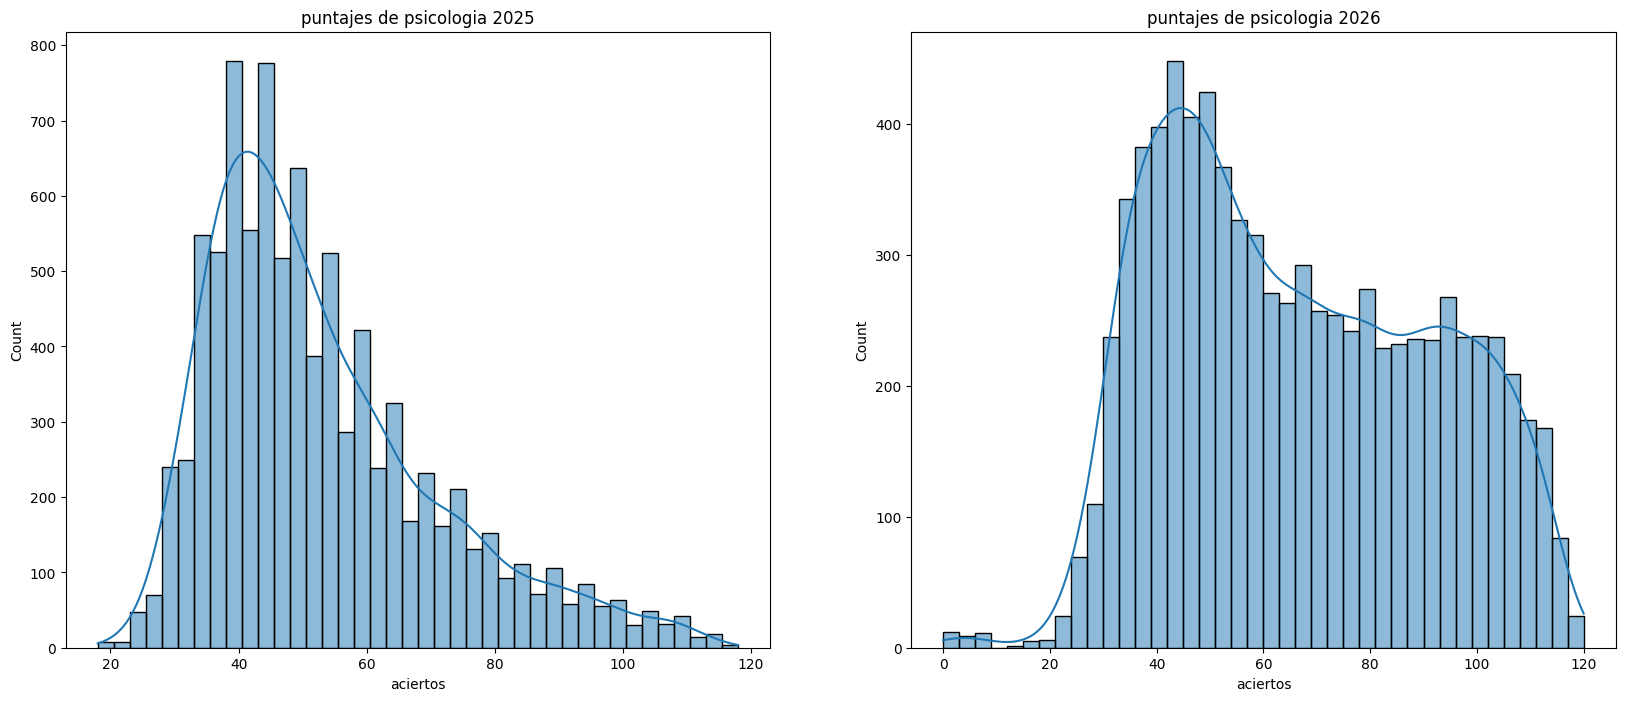

In [46]:
fig, ax = plt.subplots(1,2,figsize=(20,8))
df_escolarizado_2025_p = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'PSICOLOGIA') & (df_escolarizado_2526['year'] == 2025)].dropna(subset=['aciertos']).copy()
df_escolarizado_2026_p = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'PSICOLOGIA') & (df_escolarizado_2526['year'] == 2026)].dropna(subset=['aciertos']).copy()

ax[0].set_title('puntajes de psicologia 2025')
sns.histplot(data=df_escolarizado_2025_p,x='aciertos',kde=True,bins=40,ax=ax[0])
ax[1].set_title('puntajes de psicologia 2026')
sns.histplot(data=df_escolarizado_2026_p,x='aciertos',kde=True,bins=40,ax=ax[1])

In [47]:
describe_p2025 = df_escolarizado_2025_p.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']
describe_p2026 = df_escolarizado_2026_p.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']

tabla_psicologia = pd.DataFrame({'2025':describe_p2025,'2026':describe_p2026})
tabla_psicologia

,2025,2026
count,9028.000000,8317.000000
mean,52.863979,65.855356
std,17.986711,24.931380
min,18.000000,0.000000
25%,40.000000,45.000000
50%,48.000000,62.000000
75%,62.000000,87.000000
90%,79.000000,102.000000
99%,107.000000,114.000000
max,118.000000,120.000000


aqui tambien subieron los puntajes pero no tan fuerte como en medico o derecho. la media sube como 13 puntos y la mediana 14, tambien se nota que en 2026 hay mucha mas dispersion y la parte alta crecio bastante

In [48]:
delta_p,p_p = delta_clip(df_escolarizado_2026_p['aciertos'],df_escolarizado_2025_p['aciertos'])
delta_p,p_p

(np.float64(0.30270554478181766), np.float64(8.0683464374536745e-261))

el efecto da cerca de 0.30, es menor al de las dos carreras anteriores pero no es un cambio pequeno. parece que el cambio de 2026 tambien llego a psicologia

In [49]:
psicologia = df_escolarizado[(df_escolarizado['carrera']=='PSICOLOGIA') & df_escolarizado['aciertos'].notna()].copy()
psicologia.groupby(['year','plantel'])['aciertos'].agg(n='count',promedio='mean',mediana='median',desviacion='std',sesgo='skew',minimo='min',maximo='max')

n   promedio  \
year plantel                                                            
2023 FACULTAD DE PSICOLOGÍA                           4222  55.920180   
     FES IZTACALA                                     2526  53.607680   
     FES ZARAGOZA                                     3129  52.635986   
     TLAXCALA                                           55  50.781818   
2024 FACULTAD DE PSICOLOGÍA                           3913  54.716330   
     FES IZTACALA                                     2182  51.161320   
     FES ZARAGOZA                                     2782  51.385694   
     TLAXCALA                                           53  52.849057   
2025 FACULTAD DE PSICOLOGÍA                           3860  54.715285   
     FES IZTACALA                                     2260  51.711062   
     FES ZARAGOZA                                     2848  51.311096   
     TLAXCALA                                           60  50.900000   
2026 ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD JURIQUILLA   196  68.846939   
     FACULTAD DE PSICOLOGÍA                           3526  67.242768   
     FES IZTACALA                                     2126  65.495296   
     FES ZARAGOZA                                     2403  63.979193   
     TLAXCALA                                           66  62.757576   

                                                      mediana  desviacion  \
year plantel                                                                
2023 FACULTAD DE PSICOLOGÍA                              52.0   18.699966   
     FES IZTACALA                                        50.0   16.804340   
     FES ZARAGOZA                                        49.0   16.609460   
     TLAXCALA                                            48.0   13.561507   
2024 FACULTAD DE PSICOLOGÍA                              50.0   19.330493   
     FES IZTACALA                                        47.0   16.775689   
     FES ZARAGOZA                                        47.0   17.323032   
     TLAXCALA                                            52.0   16.755477   
2025 FACULTAD DE PSICOLOGÍA                              50.0   19.406283   
     FES IZTACALA                                        48.0   16.751581   
     FES ZARAGOZA                                        47.0   16.720437   
     TLAXCALA                                            49.0   15.365270   
2026 ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD JURIQUILLA     68.0   21.649114   
     FACULTAD DE PSICOLOGÍA                              64.0   25.862463   
     FES IZTACALA                                        62.0   24.348330   
     FES ZARAGOZA                                        60.0   24.224053   
     TLAXCALA                                            57.5   22.414323   

                                                         sesgo  minimo  maximo  
year plantel                                                                    
2023 FACULTAD DE PSICOLOGÍA                           0.838844    19.0   118.0  
     FES IZTACALA                                     0.832497    20.0   112.0  
     FES ZARAGOZA                                     0.916274    21.0   112.0  
     TLAXCALA                                         1.206432    26.0   103.0  
2024 FACULTAD DE PSICOLOGÍA                           0.942771     1.0   118.0  
     FES IZTACALA                                     1.011512    18.0   114.0  
     FES ZARAGOZA                                     0.960482    15.0   114.0  
     TLAXCALA                                         0.471694    27.0    93.0  
2025 FACULTAD DE PSICOLOGÍA                           0.985279    18.0   115.0  
     FES IZTACALA                                     1.024149    20.0   118.0  
     FES ZARAGOZA                                     1.024309    19.0   116.0  
     TLAXCALA                                         1.644271    30.0   104.0  
2026 ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD JURIQUILLA  0.037538     4.0 

el aumento aparece en facultad de psicologia, iztacala y zaragoza, asi que no parece venir de una sola sede. en 2026 tambien aparece juriquilla y eso cambia un poco la mezcla general

,grupo_gmm,media_estimada,peso_estimado
0,0,43.105685,0.438302
1,1,69.923378,0.289923
2,2,98.205024,0.271775


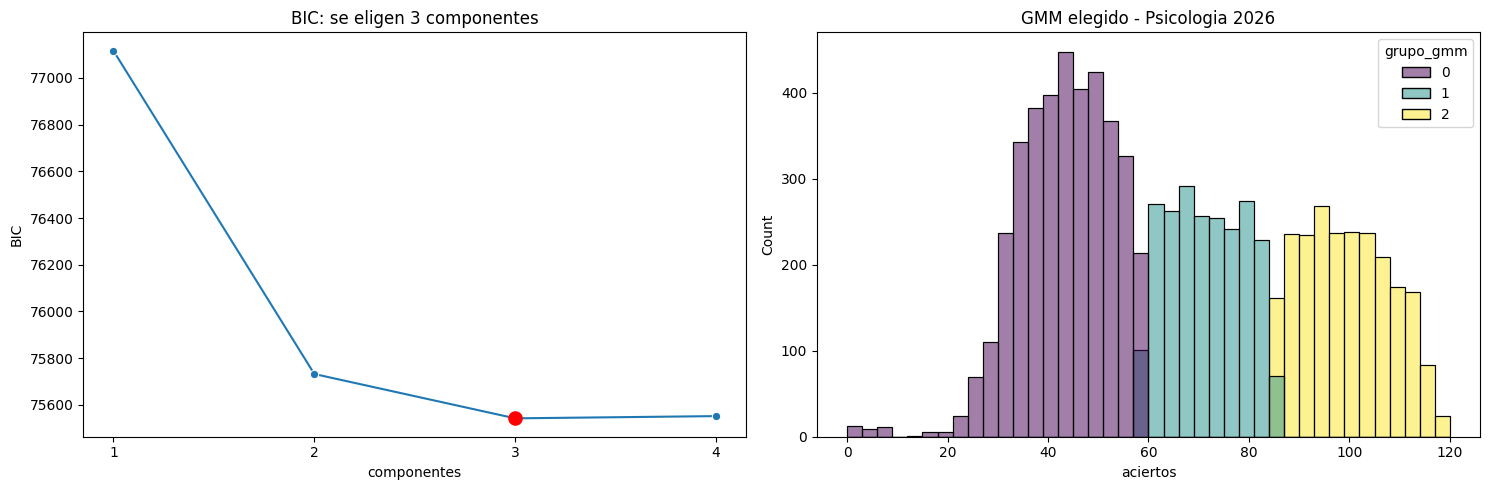

In [50]:
df_escolarizado_2026_p, bic_p, resumen_gmm_p = gmm_simple(
    df_escolarizado_2026_p, 'Psicologia 2026'
)
display(resumen_gmm_p)

el BIC prefiere tres componentes para psicologia. describe mejor la forma que imponer dos, pero los componentes siguen siendo zonas estadisticas superpuestas y no tres tipos reales de aspirantes

# ARQUITECTURA

<Axes: title={'center': 'puntajes de arquitectura 2026'}, xlabel='aciertos', ylabel='Count'>

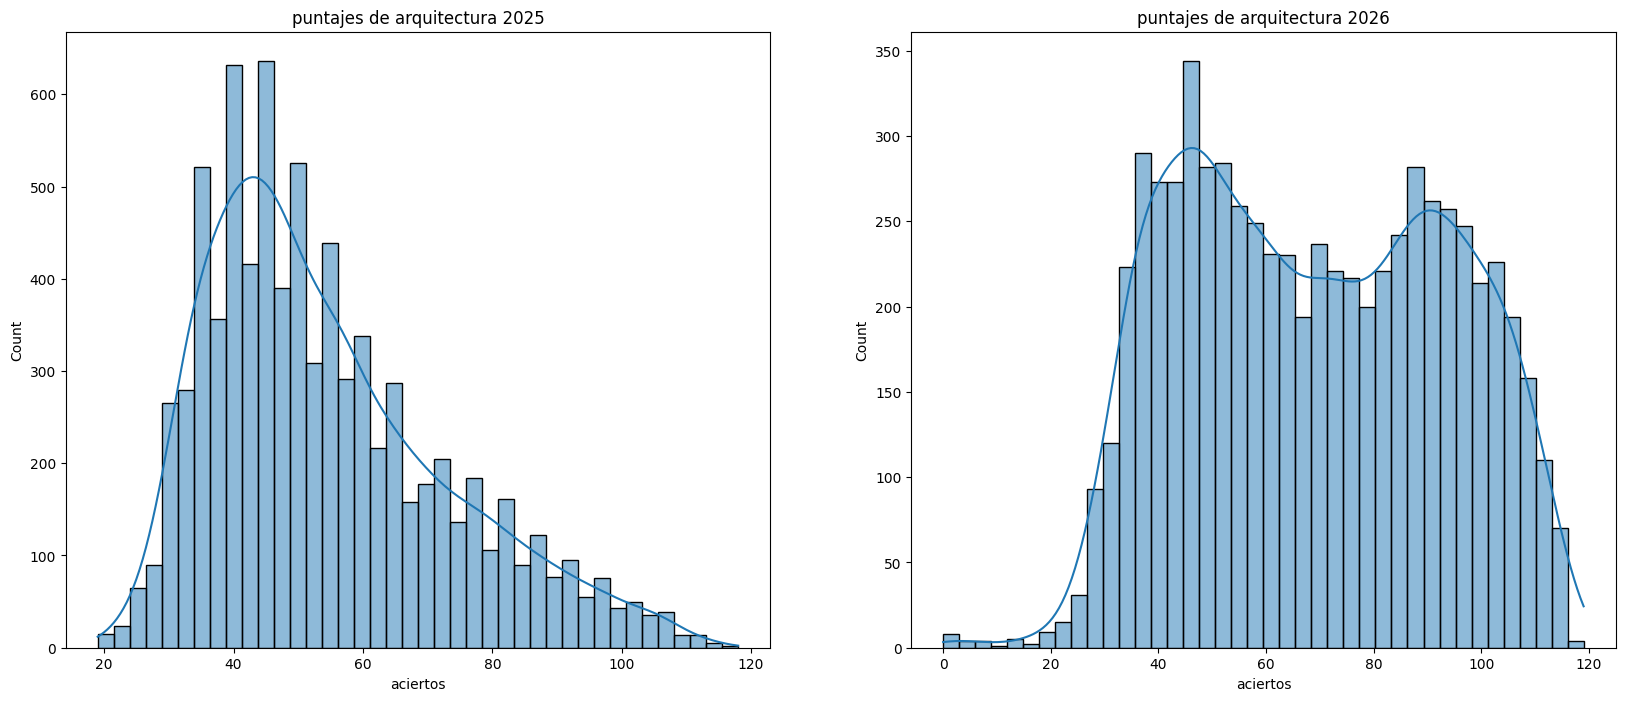

In [51]:
fig, ax = plt.subplots(1,2,figsize=(20,8))
df_escolarizado_2025_a = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'ARQUITECTURA') & (df_escolarizado_2526['year'] == 2025)].dropna(subset=['aciertos']).copy()
df_escolarizado_2026_a = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'ARQUITECTURA') & (df_escolarizado_2526['year'] == 2026)].dropna(subset=['aciertos']).copy()

ax[0].set_title('puntajes de arquitectura 2025')
sns.histplot(data=df_escolarizado_2025_a,x='aciertos',kde=True,bins=40,ax=ax[0])
ax[1].set_title('puntajes de arquitectura 2026')
sns.histplot(data=df_escolarizado_2026_a,x='aciertos',kde=True,bins=40,ax=ax[1])

In [52]:
describe_a2025 = df_escolarizado_2025_a.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']
describe_a2026 = df_escolarizado_2026_a.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']

tabla_arquitectura = pd.DataFrame({'2025':describe_a2025,'2026':describe_a2026})
tabla_arquitectura

,2025,2026
count,7941.000000,6786.000000
mean,54.262687,68.891394
std,18.564301,24.472405
min,19.000000,0.000000
25%,40.000000,48.000000
50%,50.000000,68.000000
75%,65.000000,90.000000
90%,82.000000,103.000000
99%,105.000000,114.000000
max,118.000000,119.000000


arquitectura cambia mas que psicologia: la media sube casi 15 puntos y la mediana 18. el tercer cuartil pasa de 65 a 90, entonces el movimiento se nota mucho en la mitad alta

In [53]:
delta_a,p_a = delta_clip(df_escolarizado_2026_a['aciertos'],df_escolarizado_2025_a['aciertos'])
delta_a,p_a

(np.float64(0.3497543387789992), np.float64(5.0332442387663705e-294))

el efecto es como 0.35, ya es un cambio mediano y esta entre psicologia y derecho. no parece ser solo que existan unos cuantos puntajes muy altos

In [54]:
arquitectura = df_escolarizado[(df_escolarizado['carrera']=='ARQUITECTURA') & df_escolarizado['aciertos'].notna()].copy()
arquitectura.groupby(['year','plantel'])['aciertos'].agg(n='count',promedio='mean',mediana='median',desviacion='std',sesgo='skew',minimo='min',maximo='max')

n   promedio  mediana  desviacion     sesgo  \
year plantel                                                                    
2023 FACULTAD DE ARQUITECTURA  4278  55.281440     51.5   18.302367  0.754424   
     FES ACATLÁN               1515  49.609901     47.0   15.054995  0.927747   
     FES ARAGÓN                1916  49.419102     47.0   14.805271  0.822161   
2024 FACULTAD DE ARQUITECTURA  4371  56.447495     52.0   19.703400  0.704379   
     FES ACATLÁN               1240  48.904839     46.0   15.918192  0.885458   
     FES ARAGÓN                1679  48.870161     45.0   16.101468  0.956592   
2025 FACULTAD DE ARQUITECTURA  4774  56.956850     53.0   19.784377  0.727036   
     FES ACATLÁN               1386  49.776335     47.0   14.846280  0.768456   
     FES ARAGÓN                1781  50.532285     47.0   16.344765  0.847745   
2026 FACULTAD DE ARQUITECTURA  3939  70.875857     71.0   25.017811 -0.011243   
     FES ACATLÁN               1244  65.753215     64.0   23.208822  0.106299   
     FES ARAGÓN                1603  66.450405     65.0   23.595541  0.092865   

                               minimo  maximo  
year plantel                                   
2023 FACULTAD DE ARQUITECTURA    20.0   115.0  
     FES ACATLÁN                 17.0   111.0  
     FES ARAGÓN                  21.0   104.0  
2024 FACULTAD DE ARQUITECTURA    20.0   114.0  
     FES ACATLÁN                 18.0   106.0  
     FES ARAGÓN                  18.0   113.0  
2025 FACULTAD DE ARQUITECTURA    19.0   118.0  
     FES ACATLÁN                 19.0   100.0  
     FES ARAGÓN                  19.0   110.0  
2026 FACULTAD DE ARQUITECTURA     0.0   119.0  
     FES ACATLÁN                  0.0   116.0  
     FES ARAGÓN                   3.0   116.0

facultad de arquitectura, acatlan y aragon suben en 2026. otra vez parece un cambio bastante general y no algo que solamente pase en ciudad universitaria

,grupo_gmm,media_estimada,peso_estimado
0,0,44.147453,0.389439
1,1,70.581204,0.281936
2,2,96.764534,0.328626


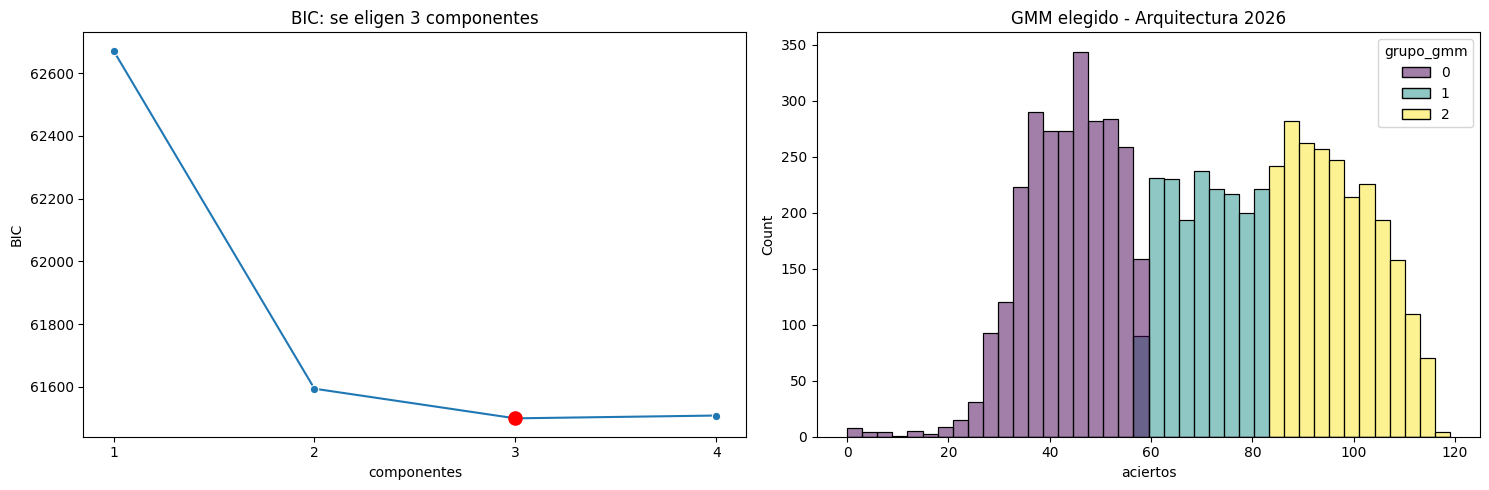

In [55]:
df_escolarizado_2026_a, bic_a, resumen_gmm_a = gmm_simple(
    df_escolarizado_2026_a, 'Arquitectura 2026'
)
display(resumen_gmm_a)

el BIC prefiere tres componentes para arquitectura, asi que dos se quedaban cortos. esto cuantifica la forma irregular, aunque no prueba que existan tres poblaciones distintas

# CIRUJANO DENTISTA

<Axes: title={'center': 'puntajes de cirujano dentista 2026'}, xlabel='aciertos', ylabel='Count'>

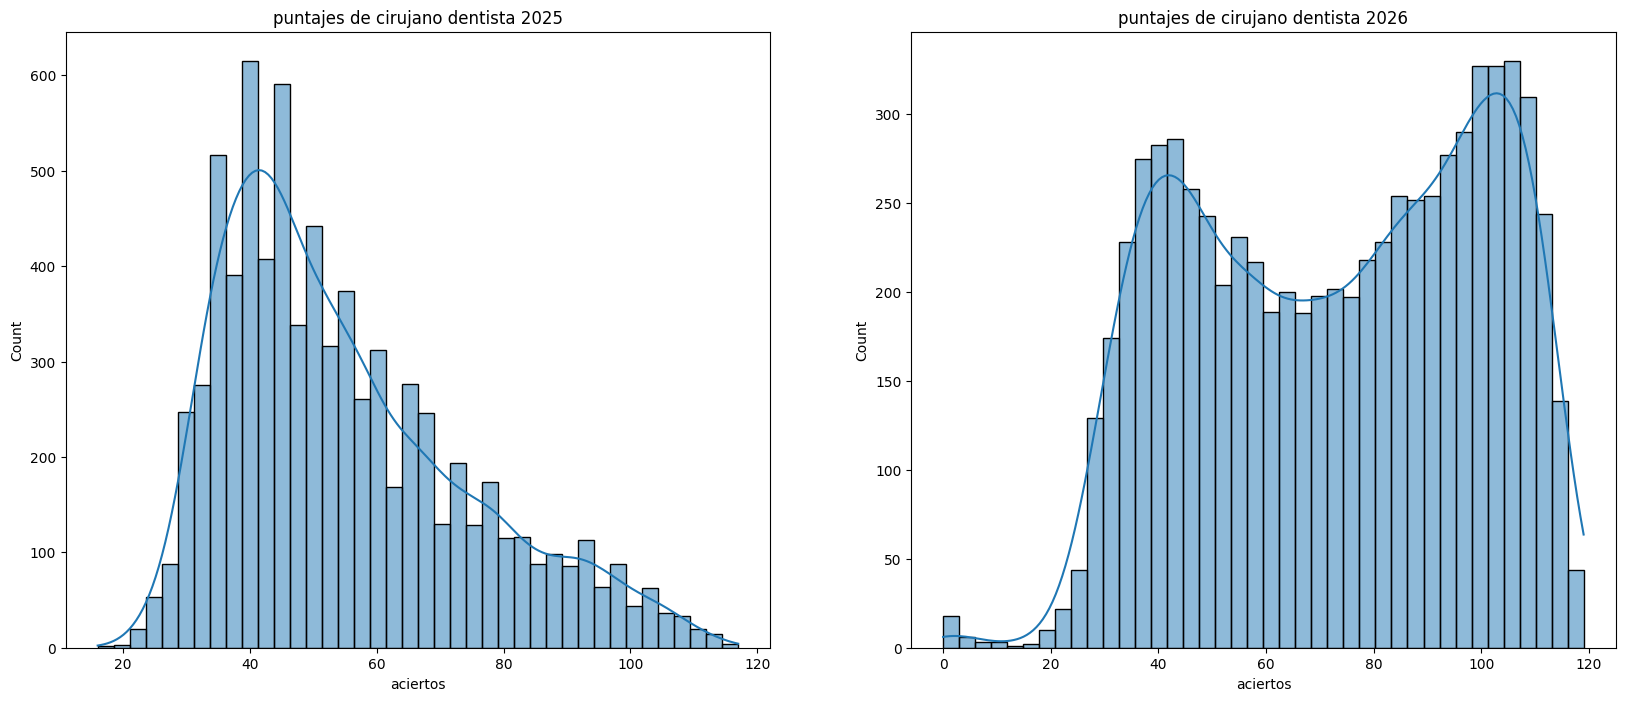

In [56]:
fig, ax = plt.subplots(1,2,figsize=(20,8))
df_escolarizado_2025_c = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'CIRUJANO DENTISTA') & (df_escolarizado_2526['year'] == 2025)].dropna(subset=['aciertos']).copy()
df_escolarizado_2026_c = df_escolarizado_2526[(df_escolarizado_2526['carrera'] == 'CIRUJANO DENTISTA') & (df_escolarizado_2526['year'] == 2026)].dropna(subset=['aciertos']).copy()

ax[0].set_title('puntajes de cirujano dentista 2025')
sns.histplot(data=df_escolarizado_2025_c,x='aciertos',kde=True,bins=40,ax=ax[0])
ax[1].set_title('puntajes de cirujano dentista 2026')
sns.histplot(data=df_escolarizado_2026_c,x='aciertos',kde=True,bins=40,ax=ax[1])

In [57]:
describe_c2025 = df_escolarizado_2025_c.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']
describe_c2026 = df_escolarizado_2026_c.describe(percentiles=[0.25,0.50,0.75,0.90,0.99])['aciertos']

tabla_cirujano_dentista = pd.DataFrame({'2025':describe_c2025,'2026':describe_c2026})
tabla_cirujano_dentista

,2025,2026
count,7550.000000,7305.000000
mean,54.739073,73.019165
std,19.320988,26.855668
min,16.000000,0.000000
25%,40.000000,48.000000
50%,50.000000,75.000000
75%,66.000000,97.000000
90%,84.000000,108.000000
99%,106.000000,116.000000
max,117.000000,119.000000


esta es la mas fuerte de estas tres: la media sube como 18 puntos y la mediana 25. el 75 por ciento pasa de 66 a 97, asi que la parte media y alta cambiaron mucho

In [58]:
delta_c,p_c = delta_clip(df_escolarizado_2026_c['aciertos'],df_escolarizado_2025_c['aciertos'])
delta_c,p_c

(np.float64(0.39555186278109433), np.float64(0.0))

el efecto es casi 0.40, un poco mayor al de derecho. aqui si hay una diferencia clara entre generaciones, aunque eso no dice cual fue la causa

In [59]:
cirujano_dentista = df_escolarizado[(df_escolarizado['carrera']=='CIRUJANO DENTISTA') & df_escolarizado['aciertos'].notna()].copy()
cirujano_dentista.groupby(['year','plantel'])['aciertos'].agg(n='count',promedio='mean',mediana='median',desviacion='std',sesgo='skew',minimo='min',maximo='max')

n   promedio  mediana  desviacion     sesgo  \
year plantel                                                                   
2023 FACULTAD DE ODONTOLOGÍA  2639  56.837438     53.0   19.231809  0.735120   
     FES IZTACALA             2437  53.261387     50.0   17.412560  0.784163   
     FES ZARAGOZA             2461  53.938236     50.0   17.712320  0.737831   
2024 FACULTAD DE ODONTOLOGÍA  2621  56.154140     51.0   20.066832  0.748786   
     FES IZTACALA             2493  53.155235     49.0   18.458262  0.829735   
     FES ZARAGOZA             2385  53.436897     49.0   18.629431  0.828345   
2025 FACULTAD DE ODONTOLOGÍA  2661  56.855318     52.0   20.736943  0.749069   
     FES IZTACALA             2511  53.123855     49.0   18.386948  0.945279   
     FES ZARAGOZA             2378  54.076535     50.0   18.415323  0.834942   
2026 FACULTAD DE ODONTOLOGÍA  2497  75.064878     78.0   27.357802 -0.216268   
     FES IZTACALA             2516  72.217011     74.0   26.483090 -0.156160   
     FES ZARAGOZA             2292  71.671030     72.5   26.588117 -0.106845   

                              minimo  maximo  
year plantel                                  
2023 FACULTAD DE ODONTOLOGÍA    17.0   118.0  
     FES IZTACALA               18.0   111.0  
     FES ZARAGOZA               18.0   113.0  
2024 FACULTAD DE ODONTOLOGÍA    21.0   119.0  
     FES IZTACALA               18.0   111.0  
     FES ZARAGOZA               13.0   113.0  
2025 FACULTAD DE ODONTOLOGÍA    19.0   117.0  
     FES IZTACALA               16.0   116.0  
     FES ZARAGOZA               17.0   113.0  
2026 FACULTAD DE ODONTOLOGÍA     0.0   119.0  
     FES IZTACALA                0.0   119.0  
     FES ZARAGOZA                0.0   119.0

odontologia, iztacala y zaragoza muestran el mismo salto, entonces no depende de un solo plantel. tambien cambia el sesgo de positivo a un poco negativo en los tres

,grupo_gmm,media_estimada,peso_estimado
0,0,40.465023,0.298182
1,1,62.850020,0.191130
2,2,85.476335,0.236745
3,3,104.783177,0.273943


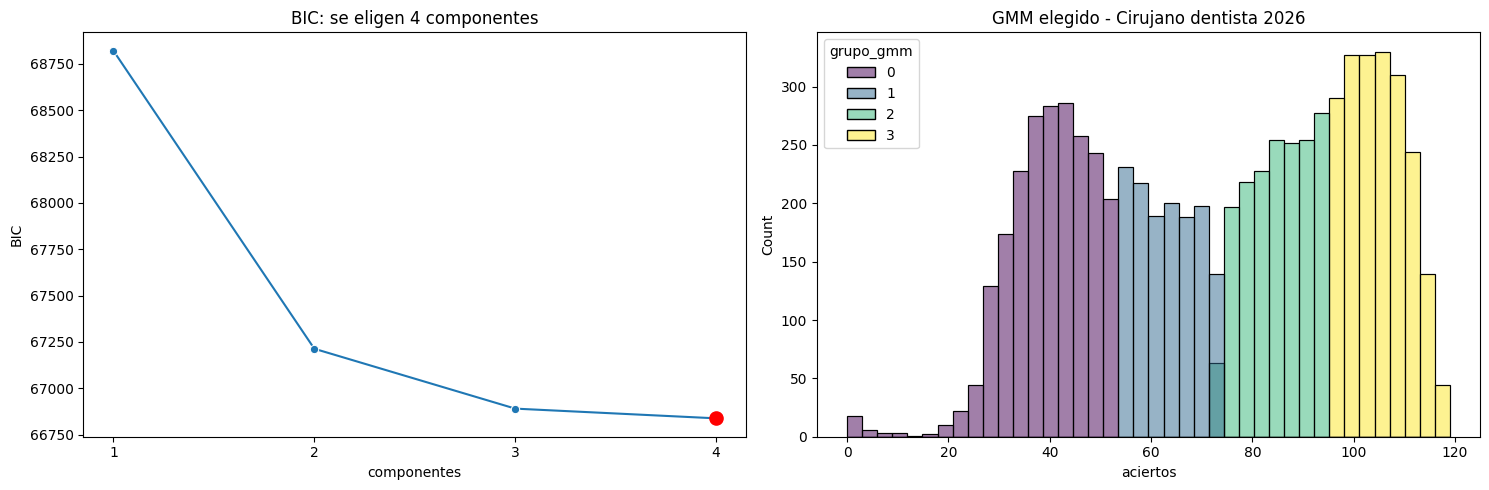

In [60]:
df_escolarizado_2026_c, bic_c, resumen_gmm_c = gmm_simple(
    df_escolarizado_2026_c, 'Cirujano dentista 2026'
)
display(resumen_gmm_c)

dentro del rango de uno a cuatro el BIC prefiere cuatro componentes para cirujano dentista. esto dice que la forma es mas compleja que una division baja-alta; no significa que existan cuatro grupos reales

Entre 2023 y 2025 las distribuciones fueron relativamente estables. En 2026 ocurrió un cambio generalizado en los puntajes, visible dentro de múltiples carreras y planteles y especialmente fuerte en la zona media y media-alta. Los cortes también aumentaron, por lo que la proporción que superó ampliamente el mínimo cambió mucho menos que los puntajes absolutos. El patrón coincide con el cambio de modalidad del examen, pero los datos disponibles no permiten atribuirle causalidad ni distinguir entre dificultad, preparación, condiciones de aplicación u otras modificaciones institucionales.

# CARRERA ALEATORIAS

veremos si carreras con menos registros tienen un comportamiento parecido. ojo: no son aleatorias en sentido estricto; el filtro elige las tres mas pequenas entre las que superan 3000 registros acumulados

<Axes: xlabel='count', ylabel='carrera'>

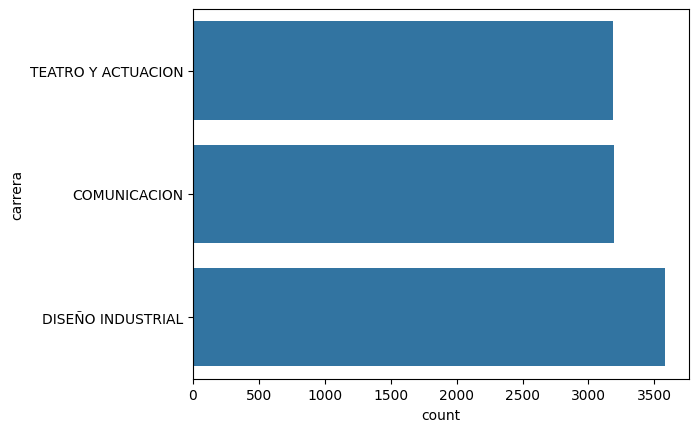

In [61]:
conteos = df_escolarizado['carrera'].value_counts()
conteos = conteos.dropna()
conteos = conteos[conteos>3000].sort_values(ascending=True).head(3)
sns.barplot(conteos,orient='h')

# TEATRO Y ACTUACION

<Axes: title={'center': 'puntajes de teatro y actuacion 2026'}, xlabel='aciertos', ylabel='Count'>

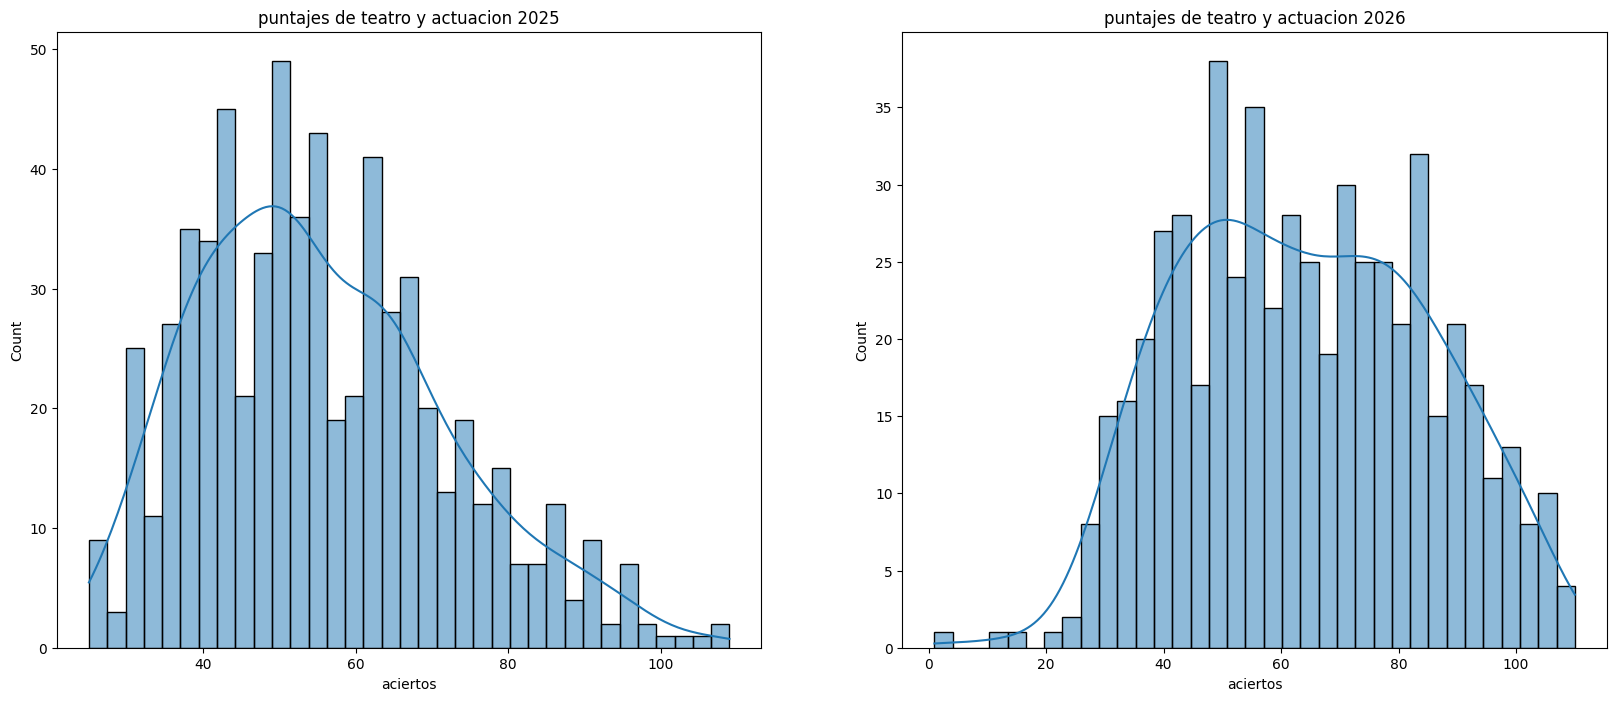

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
df_escolarizado_2025_t = df_escolarizado_2526[
    (df_escolarizado_2526['carrera'] == 'TEATRO Y ACTUACION') &
    (df_escolarizado_2526['year'] == 2025)
].dropna(subset=['aciertos']).copy()

df_escolarizado_2026_t = df_escolarizado_2526[
    (df_escolarizado_2526['carrera'] == 'TEATRO Y ACTUACION') &
    (df_escolarizado_2526['year'] == 2026)
].dropna(subset=['aciertos']).copy()

ax[0].set_title('puntajes de teatro y actuacion 2025')
sns.histplot(data=df_escolarizado_2025_t, x='aciertos', kde=True, bins=35, ax=ax[0])
ax[1].set_title('puntajes de teatro y actuacion 2026')
sns.histplot(data=df_escolarizado_2026_t, x='aciertos', kde=True, bins=35, ax=ax[1])

In [63]:
describe_t2025 = df_escolarizado_2025_t['aciertos'].describe(percentiles=[.25, .50, .75, .90, .99])
describe_t2026 = df_escolarizado_2026_t['aciertos'].describe(percentiles=[.25, .50, .75, .90, .99])

tabla_teatro = pd.DataFrame({'2025': describe_t2025, '2026': describe_t2026})
tabla_teatro

,2025,2026
count,645.000000,560.000000
mean,55.497674,63.916071
std,16.478824,20.855541
min,25.000000,1.000000
25%,43.000000,48.000000
50%,53.000000,63.000000
75%,66.000000,80.000000
90%,78.000000,92.100000
99%,97.120000,105.410000
max,109.000000,110.000000


la media sube de 55.5 a 63.9 y la mediana de 53 a 63. si existe un movimiento, aunque visualmente es menos fuerte que en las carreras grandes

# PRUEBA DE MANN-WHITNEY Y DELTA DE CLIFF

In [64]:
delta_t, p_t = delta_clip(
    df_escolarizado_2026_t['aciertos'],
    df_escolarizado_2025_t['aciertos']
)
delta_t, p_t

(np.float64(0.24034606866002206), np.float64(5.788234278533521e-13))

el delta es cercano a 0.24. el cambio es estadisticamente claro, pero su tamano es pequeno a mediano y menor que en medico, derecho o arquitectura

In [65]:
teatro = df_escolarizado[
    (df_escolarizado['carrera'] == 'TEATRO Y ACTUACION') &
    df_escolarizado['aciertos'].notna()
].copy()

teatro.groupby(['year', 'plantel'])['aciertos'].agg(
    n='count', promedio='mean', mediana='median', desviacion='std',
    sesgo='skew', minimo='min', maximo='max'
)

,,n,promedio,mediana,desviacion,sesgo,minimo,maximo
year,plantel,,,,,,,
2023,FACULTAD DE MÚSICA,760,55.284211,53.0,17.327376,0.615496,24.0,107.0
2024,FACULTAD DE MÚSICA,615,55.731707,52.0,17.012389,0.592183,24.0,108.0
2025,FACULTAD DE MÚSICA,645,55.497674,53.0,16.478824,0.582204,25.0,109.0
2026,FACULTAD DE MÚSICA,560,63.916071,63.0,20.855541,0.070952,1.0,110.0


en 2025 y 2026 los registros son de facultad de musica, por lo que el salto no se puede explicar por mezclar planteles distintos

,componentes,BIC
0,1,5003.000162
1,2,4983.706902
2,3,5001.364932
3,4,5020.638714


,grupo_gmm,media_estimada,peso_estimado
0,0,48.765149,0.543248
1,1,81.936149,0.456752


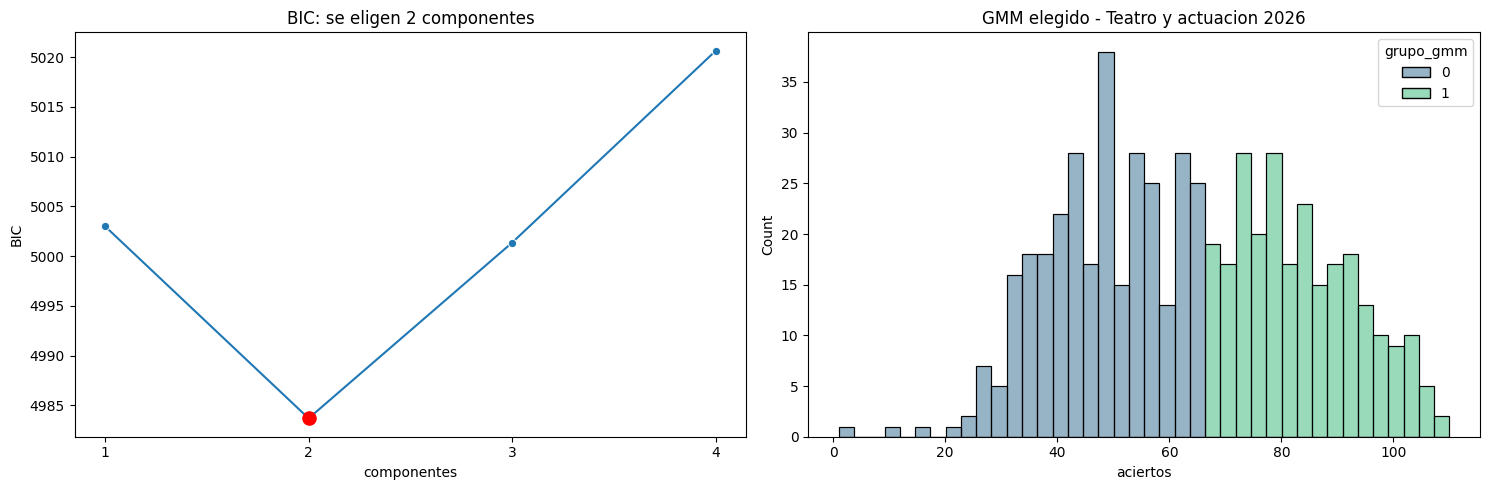

In [66]:
df_escolarizado_2026_t, bic_teatro, resumen_gmm_teatro = gmm_simple(
    df_escolarizado_2026_t, 'Teatro y actuacion 2026'
)
display(bic_teatro)
display(resumen_gmm_teatro)

el BIC elige dos componentes, con centros aproximados en 49 y 82 aciertos. es evidencia de que una sola normal describe mal la forma, pero no demuestra que existan dos clases reales de estudiantes

# COMUNICACION

<Axes: title={'center': 'puntajes de comunicacion 2026'}, xlabel='aciertos', ylabel='Count'>

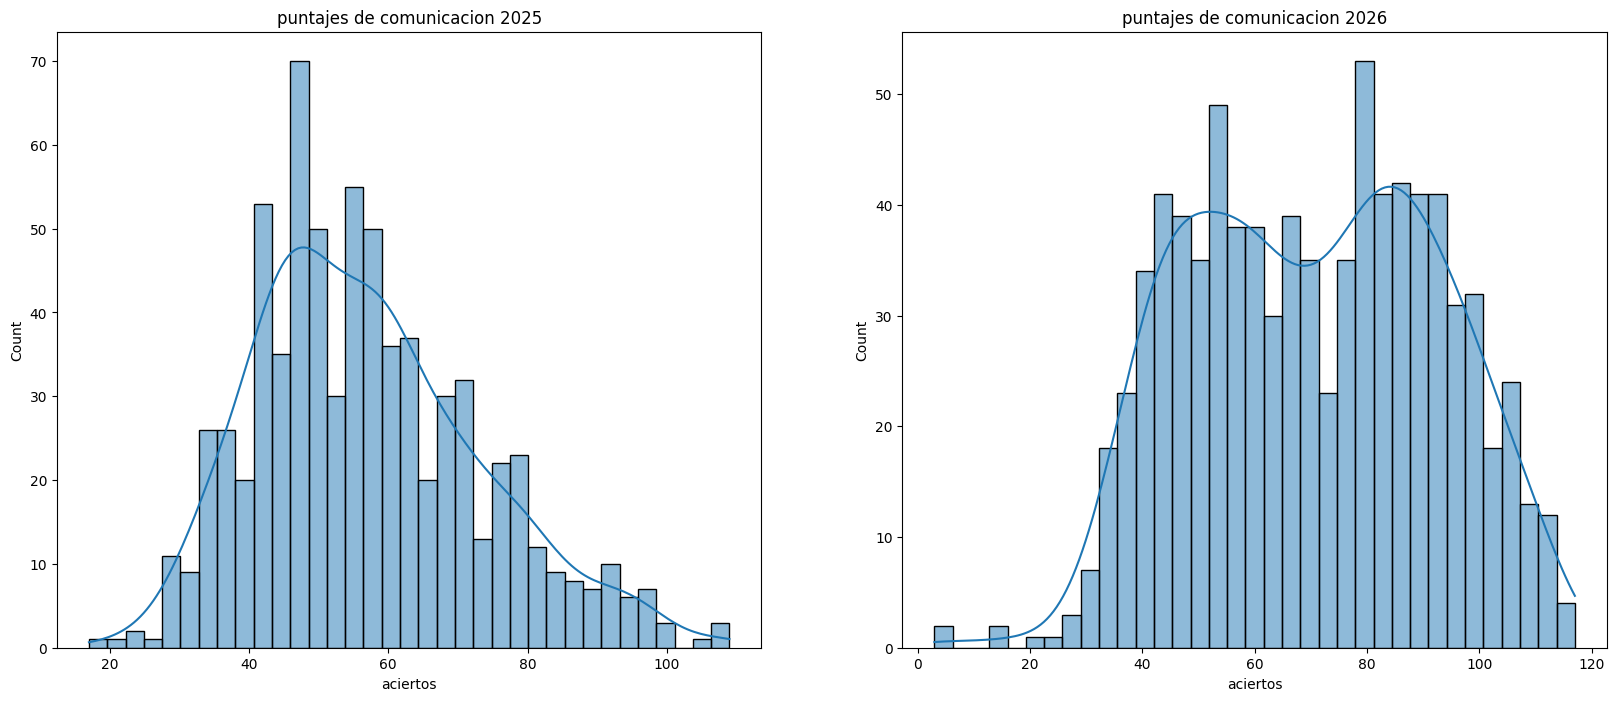

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
df_escolarizado_2025_co = df_escolarizado_2526[
    (df_escolarizado_2526['carrera'] == 'COMUNICACION') &
    (df_escolarizado_2526['year'] == 2025)
].dropna(subset=['aciertos']).copy()

df_escolarizado_2026_co = df_escolarizado_2526[
    (df_escolarizado_2526['carrera'] == 'COMUNICACION') &
    (df_escolarizado_2526['year'] == 2026)
].dropna(subset=['aciertos']).copy()

ax[0].set_title('puntajes de comunicacion 2025')
sns.histplot(data=df_escolarizado_2025_co, x='aciertos', kde=True, bins=35, ax=ax[0])
ax[1].set_title('puntajes de comunicacion 2026')
sns.histplot(data=df_escolarizado_2026_co, x='aciertos', kde=True, bins=35, ax=ax[1])

In [68]:
describe_co2025 = df_escolarizado_2025_co['aciertos'].describe(percentiles=[.25, .50, .75, .90, .99])
describe_co2026 = df_escolarizado_2026_co['aciertos'].describe(percentiles=[.25, .50, .75, .90, .99])

tabla_comunicacion = pd.DataFrame({'2025': describe_co2025, '2026': describe_co2026})
tabla_comunicacion

,2025,2026
count,719.000000,845.000000
mean,56.976356,70.231953
std,16.251274,21.914378
min,17.000000,3.000000
25%,45.000000,52.000000
50%,55.000000,70.000000
75%,67.000000,88.000000
90%,80.000000,99.000000
99%,98.000000,112.000000
max,109.000000,117.000000


la media sube de 57.0 a 70.2 y la mediana de 55 a 70. el desplazamiento se nota tanto en el centro como en la parte alta de la distribucion

# PRUEBA DE MANN-WHITNEY Y DELTA DE CLIFF

In [69]:
delta_co, p_co = delta_clip(
    df_escolarizado_2026_co['aciertos'],
    df_escolarizado_2025_co['aciertos']
)
delta_co, p_co

(np.float64(0.3565273925817416), np.float64(4.5679762669308925e-34))

el delta es cercano a 0.36, un efecto mediano. esto indica que el cambio no depende solamente de unos pocos puntajes extremos

In [70]:
comunicacion = df_escolarizado[
    (df_escolarizado['carrera'] == 'COMUNICACION') &
    df_escolarizado['aciertos'].notna()
].copy()

comunicacion.groupby(['year', 'plantel'])['aciertos'].agg(
    n='count', promedio='mean', mediana='median', desviacion='std',
    sesgo='skew', minimo='min', maximo='max'
)

n   promedio  mediana  \
year plantel                                                              
2023 FES ACATLÁN                                642  57.419003     54.0   
2024 FES ACATLÁN                                526  58.182510     55.0   
2025 FES ACATLÁN                                719  56.976356     55.0   
2026 ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD LEÓN   82  67.536585     62.0   
     FES ACATLÁN                                763  70.521625     71.0   

                                                desviacion     sesgo  minimo  \
year plantel                                                                   
2023 FES ACATLÁN                                 18.638121  0.588175    23.0   
2024 FES ACATLÁN                                 17.807033  0.630426    24.0   
2025 FES ACATLÁN                                 16.251274  0.584872    17.0   
2026 ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD LEÓN   23.161374  0.299962    20.0   
     FES ACATLÁN                                 21.772216 -0.075337     3.0   

                                                maximo  
year plantel                                            
2023 FES ACATLÁN                                 109.0  
2024 FES ACATLÁN                                 112.0  
2025 FES ACATLÁN                                 109.0  
2026 ESCUELA NAL. DE ESTUDIOS SUP. UNIDAD LEÓN   114.0  
     FES ACATLÁN                                 117.0

en 2026 aparece la unidad leon, pero acatlan por si sola tambien sube. por eso el cambio general no depende solamente del plantel nuevo

,componentes,BIC
0,1,7627.755807
1,2,7562.747544
2,3,7582.437144
3,4,7602.960339


,grupo_gmm,media_estimada,peso_estimado
0,0,52.301376,0.500241
1,1,88.179817,0.499759


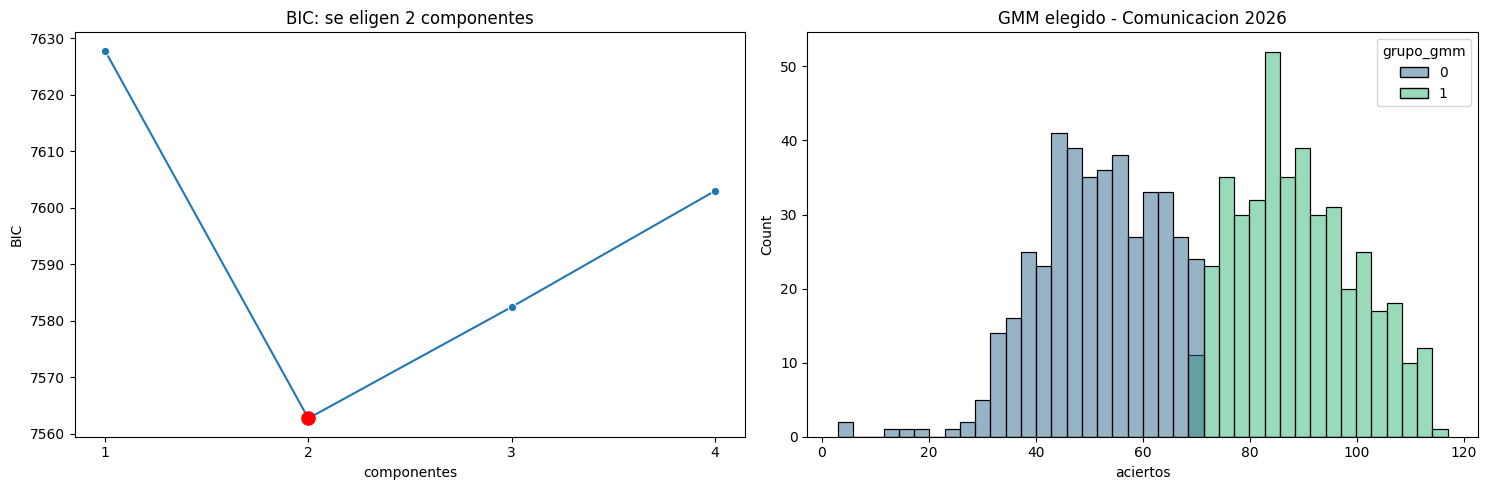

In [71]:
df_escolarizado_2026_co, bic_comunicacion, resumen_gmm_comunicacion = gmm_simple(
    df_escolarizado_2026_co, 'Comunicacion 2026'
)
display(bic_comunicacion)
display(resumen_gmm_comunicacion)

el BIC tambien elige dos componentes, alrededor de 52 y 88 aciertos y con pesos parecidos. la separacion es descriptiva; todavia podria reflejar plantel, seleccion, forma del examen u otras variables que no tenemos

# DISENO INDUSTRIAL

<Axes: title={'center': 'puntajes de diseno industrial 2026'}, xlabel='aciertos', ylabel='Count'>

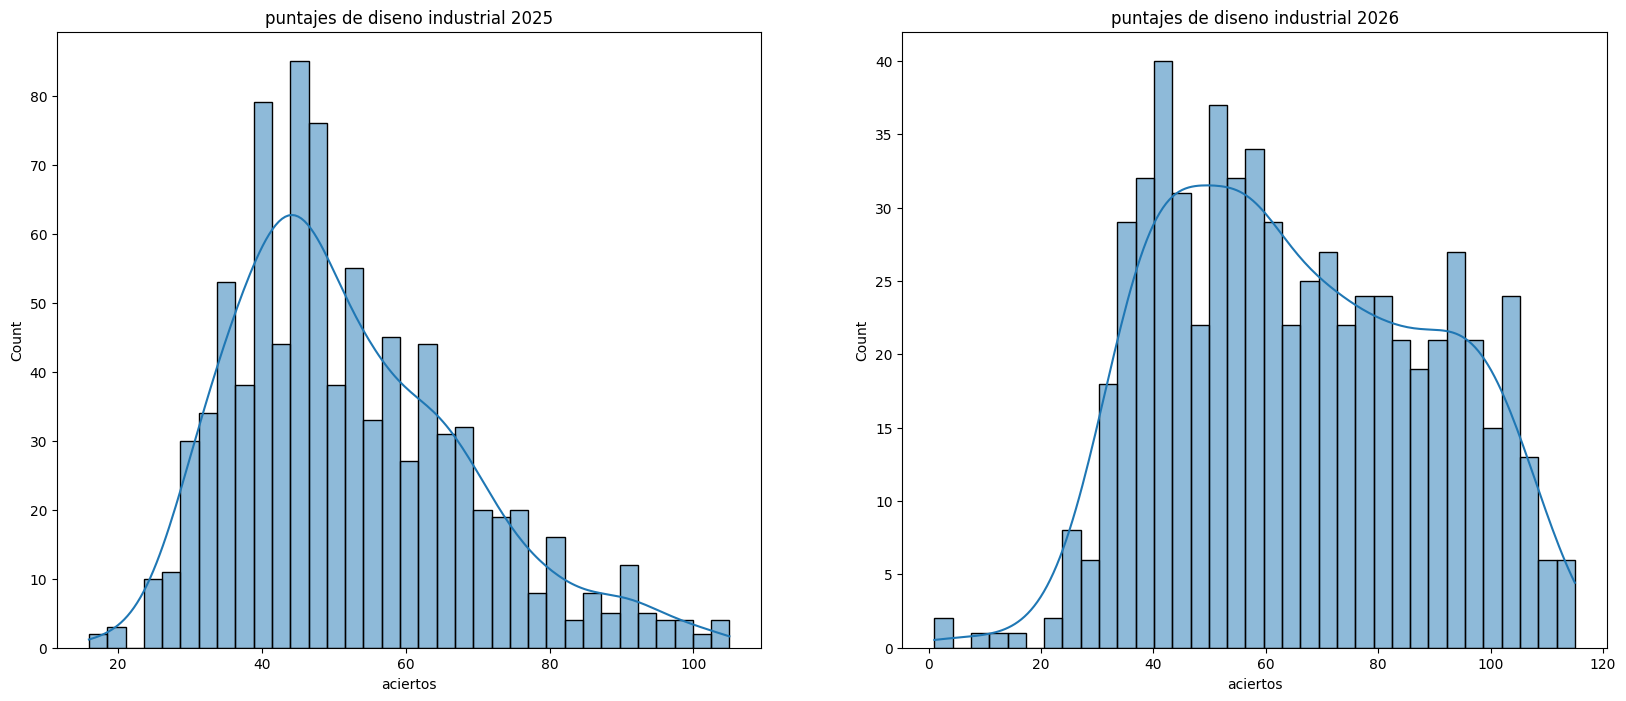

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
df_escolarizado_2025_di = df_escolarizado_2526[
    (df_escolarizado_2526['carrera'] == 'DISEÑO INDUSTRIAL') &
    (df_escolarizado_2526['year'] == 2025)
].dropna(subset=['aciertos']).copy()

df_escolarizado_2026_di = df_escolarizado_2526[
    (df_escolarizado_2526['carrera'] == 'DISEÑO INDUSTRIAL') &
    (df_escolarizado_2526['year'] == 2026)
].dropna(subset=['aciertos']).copy()

ax[0].set_title('puntajes de diseno industrial 2025')
sns.histplot(data=df_escolarizado_2025_di, x='aciertos', kde=True, bins=35, ax=ax[0])
ax[1].set_title('puntajes de diseno industrial 2026')
sns.histplot(data=df_escolarizado_2026_di, x='aciertos', kde=True, bins=35, ax=ax[1])

In [73]:
describe_di2025 = df_escolarizado_2025_di['aciertos'].describe(percentiles=[.25, .50, .75, .90, .99])
describe_di2026 = df_escolarizado_2026_di['aciertos'].describe(percentiles=[.25, .50, .75, .90, .99])

tabla_diseno = pd.DataFrame({'2025': describe_di2025, '2026': describe_di2026})
tabla_diseno

,2025,2026
count,901.000000,642.000000
mean,52.108768,65.253894
std,16.270674,23.376910
min,16.000000,1.000000
25%,40.000000,45.250000
50%,49.000000,62.000000
75%,62.000000,84.000000
90%,75.000000,98.000000
99%,98.000000,110.590000
max,105.000000,115.000000


la media sube de 52.1 a 65.3 y la mediana de 49 a 62. el movimiento es parecido al de comunicacion y bastante visible en la zona media

# PRUEBA DE MANN-WHITNEY Y DELTA DE CLIFF

In [74]:
delta_di, p_di = delta_clip(
    df_escolarizado_2026_di['aciertos'],
    df_escolarizado_2025_di['aciertos']
)
delta_di, p_di

(np.float64(0.3315336714830528), np.float64(1.0466853657026248e-28))

el delta es cercano a 0.33, tambien un efecto mediano. el aumento no se limita a unos cuantos casos atipicos

In [75]:
diseno_industrial = df_escolarizado[
    (df_escolarizado['carrera'] == 'DISEÑO INDUSTRIAL') &
    df_escolarizado['aciertos'].notna()
].copy()

diseno_industrial.groupby(['year', 'plantel'])['aciertos'].agg(
    n='count', promedio='mean', mediana='median', desviacion='std',
    sesgo='skew', minimo='min', maximo='max'
)

,,n,promedio,mediana,desviacion,sesgo,minimo,maximo
year,plantel,,,,,,,
2023,FES ARAGÓN,648,51.847222,48.0,15.654593,0.905017,25.0,108.0
2024,FES ARAGÓN,776,50.677835,47.0,16.494905,0.841636,19.0,107.0
2025,FES ARAGÓN,901,52.108768,49.0,16.270674,0.752432,16.0,105.0
2026,FES ARAGÓN,642,65.253894,62.0,23.376910,0.150627,1.0,115.0


los registros de 2025 y 2026 son de fes aragon, por lo que el aumento no viene de un cambio en la mezcla de sedes

,componentes,BIC
0,1,5880.690885
1,2,5828.535677
2,3,5837.223362
3,4,5855.117009


,grupo_gmm,media_estimada,peso_estimado
0,0,48.379363,0.559731
1,1,86.707126,0.440269


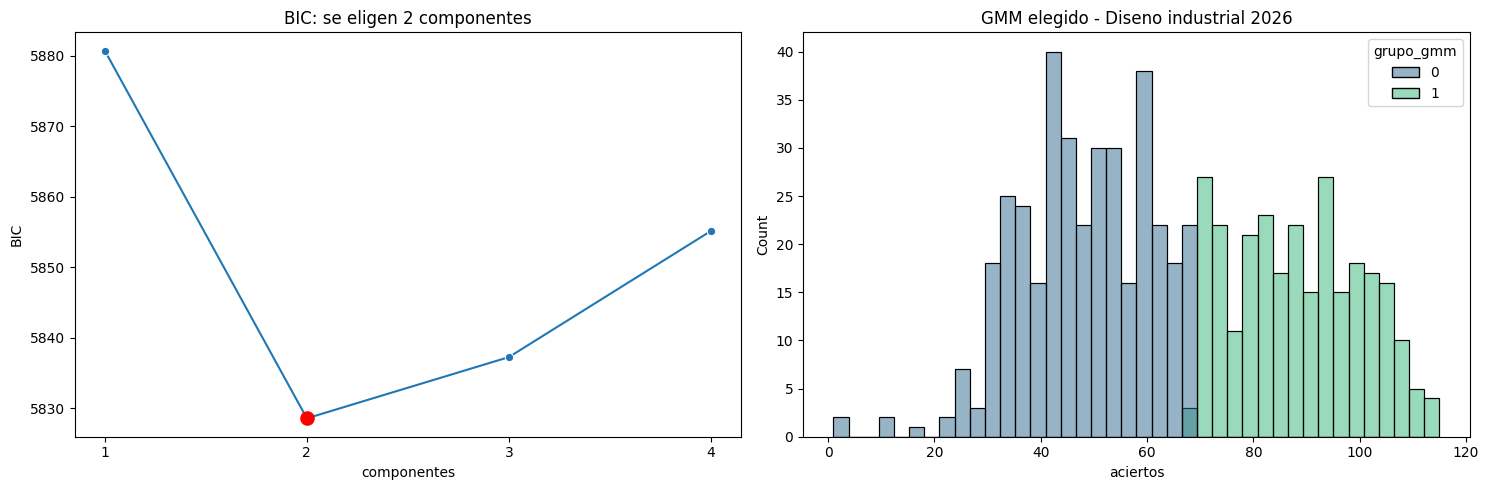

In [76]:
df_escolarizado_2026_di, bic_diseno, resumen_gmm_diseno = gmm_simple(
    df_escolarizado_2026_di, 'Diseno industrial 2026'
)
display(bic_diseno)
display(resumen_gmm_diseno)